# Creates LULUCF figures

In [16]:
import pandas as pd
import yaml
import geodatasets
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
import pygwalker as pyg
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import glob
import gc
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm import tqdm

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

### Input table paths (zonal stats, and chunk stats for comparison purposes)

In [3]:
# LULUCF outputs
LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')
LULUCF_zonal_stats_folder

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1')

In [4]:
# Reads wide LULUCF table 
LULUCF_for_figures = pd.read_parquet(f'{LULUCF_zonal_stats_folder}/LULUCF__v{cn.LULUCF_model_version_underscore}__for_figures__wide__20260606.parquet')

### Figure creation

In [5]:
# Column names in LULUCF_wide
COL_MINERAL_SOIL_NET = 'SOC_net__mineral_soil_extent__0-30cm_MgCO2'
COL_MINERAL_SOIL_LOSS = 'SOC_loss__mineral_soil_extent__0-30cm_MgCO2'
COL_MINERAL_SOIL_GAIN = 'SOC_gain__mineral_soil_extent__0-30cm_MgCO2'
COL_ORGANIC_SOIL = 'organic_soil_emis_total__MgCO2e'
COL_VEG_EMIS     = 'gross_emissions__all_C_pools__all_gases__MgCO2e'
COL_VEG_REMOV    = 'gross_removals__all_C_pools__MgCO2'
COL_LULUCF_NET   = 'LULUCF_net_flux__MgCO2e'

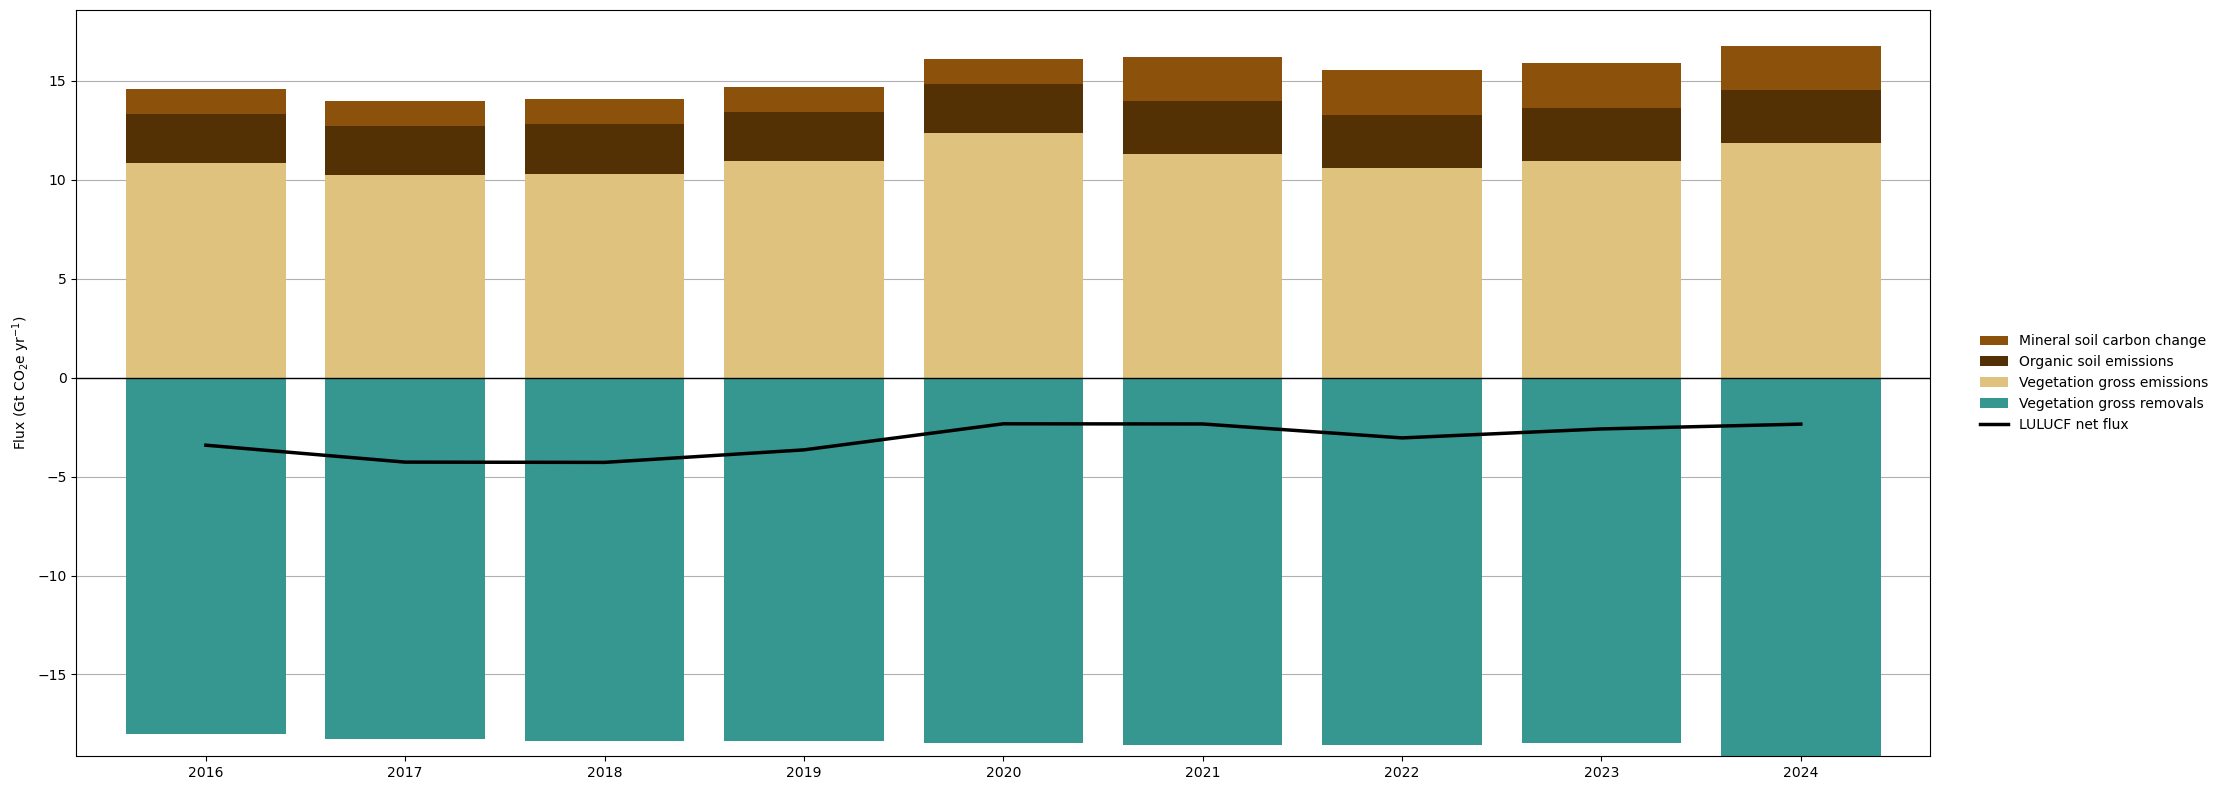

,SOC_net__mineral_soil_extent__0-30cm_MgCO2,organic_soil_emis_total__MgCO2e,gross_emissions__all_C_pools__all_gases__MgCO2e,gross_removals__all_C_pools__MgCO2,LULUCF_net_flux__MgCO2e
year,,,,,
2016,1.264591,2.481465,10.849560,-18.007427,-3.411812
2017,1.264591,2.481465,10.228782,-18.242174,-4.267337
2018,1.264591,2.481465,10.315666,-18.342005,-4.280283
2019,1.264591,2.481465,10.949894,-18.343779,-3.647827
2020,1.264591,2.481465,12.362819,-18.439075,-2.330203
2021,2.252878,2.669555,11.308680,-18.570160,-2.339048
2022,2.252878,2.669555,10.614023,-18.580580,-3.044123
2023,2.252878,2.669555,10.973489,-18.485804,-2.589881
2024,2.252878,2.669555,11.863525,-19.133179,-2.347219


In [6]:
### Global LULUCF components with gross veg and organic soil and net mineral as bars and net LULUCF as line (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6d457-96b4-8328-9fca-ff50f8273233
### and then Claude session 'LULUCF and component table creation'
### Colors consistent with LULUCF maps from Claude (session 'LULUCF graph color consistency with maps')

desired_bar_order  = [COL_MINERAL_SOIL_NET, COL_ORGANIC_SOIL, COL_VEG_EMIS, COL_VEG_REMOV]
desired_line_order = [COL_LULUCF_NET]

color_map = {
    COL_MINERAL_SOIL_NET: "#8c510a",
    COL_ORGANIC_SOIL: "#543005",
    COL_VEG_EMIS:     "#dfc27d",
    COL_VEG_REMOV:    "#35978f",
    COL_LULUCF_NET:   "#000000",
}

label_map = {
    COL_MINERAL_SOIL_NET: "Mineral soil carbon change",
    COL_ORGANIC_SOIL: "Organic soil emissions",
    COL_VEG_EMIS:     "Vegetation gross emissions",
    COL_VEG_REMOV:    "Vegetation gross removals",
    COL_LULUCF_NET:   "LULUCF net flux",
}

# Sum by year across all contextual combinations, convert to Gt CO2e/yr
plot_cols = desired_bar_order + desired_line_order
df_wide = (
    LULUCF_for_figures
    .groupby('year')[plot_cols]
    .sum()
    .rename(index=lambda y: int(y))
    .sort_index()
    / 1e9
)

bar_cols  = [c for c in desired_bar_order  if c in df_wide.columns]
line_cols = [c for c in desired_line_order if c in df_wide.columns]

df_bars = df_wide[bar_cols[::-1]]   # Reversed for correct stacking order
df_pos  = df_bars.clip(lower=0)
df_neg  = df_bars.clip(upper=0)

fig, ax = plt.subplots(figsize=(28, 8))

df_pos.plot(kind="bar", stacked=True, ax=ax, width=0.8,
            color=[color_map[c] for c in df_pos.columns])
df_neg.plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
            color=[color_map[c] for c in df_neg.columns])

x = np.arange(len(df_wide.index))
for col in line_cols:
    ax.plot(x, df_wide[col].values, linewidth=2.5, label=col,
            color=color_map.get(col, "black"), zorder=5)

ax.axhline(0, color="black", linewidth=1)
ax.grid(visible=True, axis="y")
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.set_xlabel(None)
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
ax.set_xticks(x)
ax.set_xticklabels(df_wide.index, rotation=0)

handles, labels = ax.get_legend_handles_labels()
label_to_handle  = dict(zip(labels, handles))
ordered_labels   = [l for l in desired_bar_order + desired_line_order if l in label_to_handle]
ax.legend(
    [label_to_handle[l] for l in ordered_labels],
    [label_map.get(l, l) for l in ordered_labels],
    title="", loc="center left", bbox_to_anchor=(1.02, 0.5),
    ncol=1, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_global_timeseries_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()
display(df_wide)

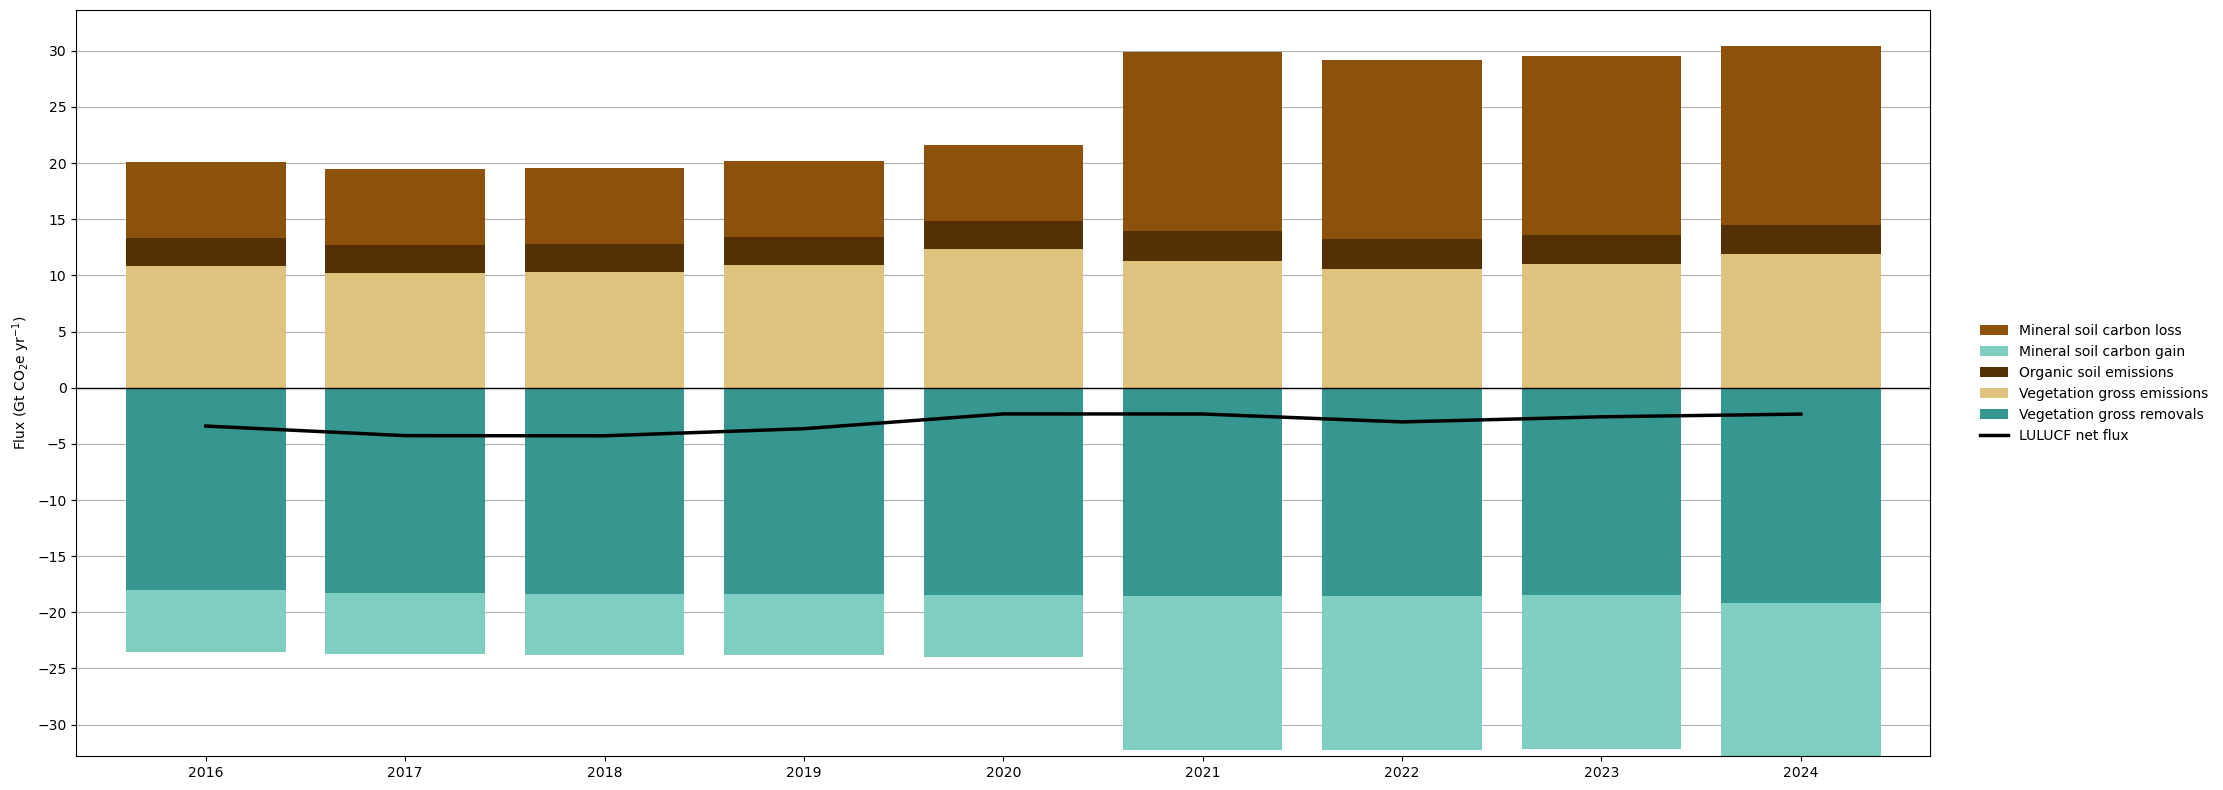

,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2,organic_soil_emis_total__MgCO2e,gross_emissions__all_C_pools__all_gases__MgCO2e,gross_removals__all_C_pools__MgCO2,LULUCF_net_flux__MgCO2e
year,,,,,,
2016,6.760377,-5.495787,2.481465,10.849560,-18.007427,-3.411812
2017,6.760377,-5.495787,2.481465,10.228782,-18.242174,-4.267337
2018,6.760377,-5.495787,2.481465,10.315666,-18.342005,-4.280283
2019,6.760377,-5.495787,2.481465,10.949894,-18.343779,-3.647827
2020,6.760377,-5.495787,2.481465,12.362819,-18.439075,-2.330203
2021,15.937722,-13.684845,2.669555,11.308680,-18.570160,-2.339048
2022,15.937722,-13.684845,2.669555,10.614023,-18.580580,-3.044123
2023,15.937722,-13.684845,2.669555,10.973489,-18.485804,-2.589881
2024,15.937722,-13.684845,2.669555,11.863525,-19.133179,-2.347219


In [7]:
### Global LULUCF components with gross veg, mineral, and organic soil as bars and net LULUCF as line (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6d457-96b4-8328-9fca-ff50f8273233
### and then Claude session 'LULUCF and component table creation'
### Colors consistent with LULUCF maps from Claude (session 'LULUCF graph color consistency with maps')

desired_bar_order  = [COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN, COL_ORGANIC_SOIL, COL_VEG_EMIS, COL_VEG_REMOV]
desired_line_order = [COL_LULUCF_NET]

color_map = {
    COL_MINERAL_SOIL_LOSS: "#8c510a",
    COL_MINERAL_SOIL_GAIN: "#80cdc1",
    COL_ORGANIC_SOIL:      "#543005",
    COL_VEG_EMIS:          "#dfc27d",
    COL_VEG_REMOV:         "#35978f",
    COL_LULUCF_NET:        "#000000",
}

label_map = {
    COL_MINERAL_SOIL_LOSS: "Mineral soil carbon loss",
    COL_MINERAL_SOIL_GAIN: "Mineral soil carbon gain",
    COL_ORGANIC_SOIL:      "Organic soil emissions",
    COL_VEG_EMIS:          "Vegetation gross emissions",
    COL_VEG_REMOV:         "Vegetation gross removals",
    COL_LULUCF_NET:        "LULUCF net flux",
}

# Sum by year across all contextual combinations, convert to Gt CO2e/yr
plot_cols = desired_bar_order + desired_line_order
df_wide = (
    LULUCF_for_figures
    .groupby('year')[plot_cols]
    .sum()
    .rename(index=lambda y: int(y))
    .sort_index()
    / 1e9
)

bar_cols  = [c for c in desired_bar_order  if c in df_wide.columns]
line_cols = [c for c in desired_line_order if c in df_wide.columns]

df_bars = df_wide[bar_cols[::-1]]   # Reversed for correct stacking order
df_pos  = df_bars.clip(lower=0)
df_neg  = df_bars.clip(upper=0)

fig, ax = plt.subplots(figsize=(28, 8))

df_pos.plot(kind="bar", stacked=True, ax=ax, width=0.8,
            color=[color_map[c] for c in df_pos.columns])
df_neg.plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
            color=[color_map[c] for c in df_neg.columns])

x = np.arange(len(df_wide.index))
for col in line_cols:
    ax.plot(x, df_wide[col].values, linewidth=2.5, label=col,
            color=color_map.get(col, "black"), zorder=5)

ax.axhline(0, color="black", linewidth=1)
ax.grid(visible=True, axis="y")
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.set_xlabel(None)
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
ax.set_xticks(x)
ax.set_xticklabels(df_wide.index, rotation=0)

handles, labels = ax.get_legend_handles_labels()
label_to_handle  = dict(zip(labels, handles))
ordered_labels   = [l for l in desired_bar_order + desired_line_order if l in label_to_handle]
ax.legend(
    [label_to_handle[l] for l in ordered_labels],
    [label_map.get(l, l) for l in ordered_labels],
    title="", loc="center left", bbox_to_anchor=(1.02, 0.5),
    ncol=1, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_global_timeseries_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()
display(df_wide)

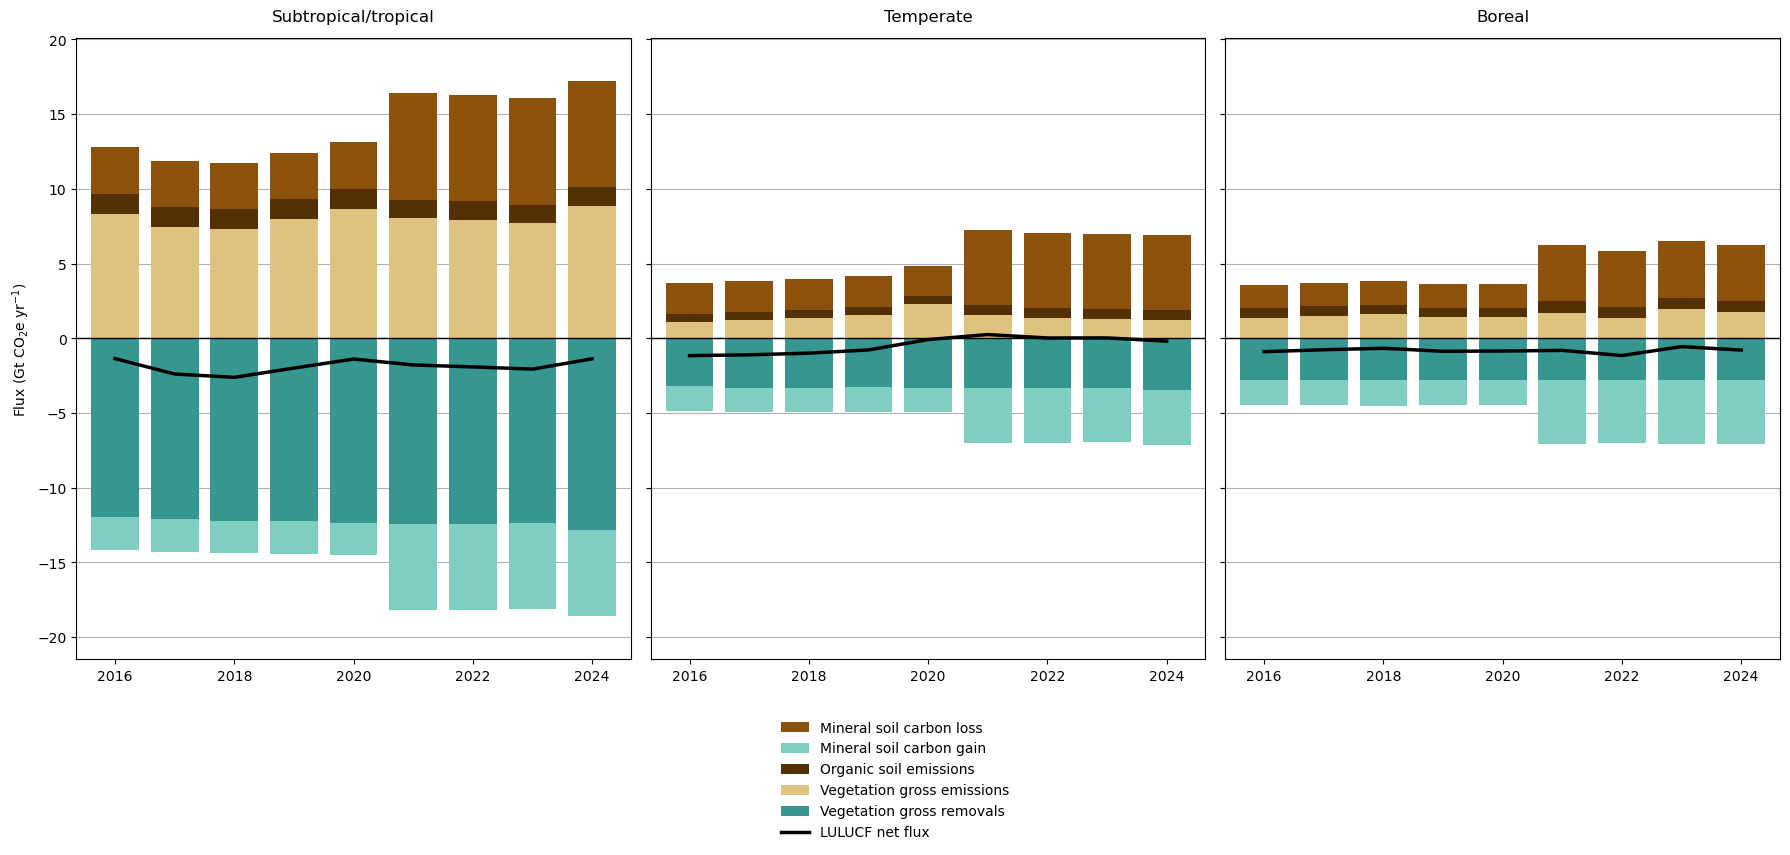

,climate_domain,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2,organic_soil_emis_total__MgCO2e,gross_emissions__all_C_pools__all_gases__MgCO2e,gross_removals__all_C_pools__MgCO2,LULUCF_net_flux__MgCO2e
year,,,,,,,
2016,Subtropical/tropical,3.115733,-2.167166,1.333026,8.349042,-11.986712,-1.356077
2017,Subtropical/tropical,3.115733,-2.167166,1.333026,7.451663,-12.121479,-2.388222
2018,Subtropical/tropical,3.115733,-2.167166,1.333026,7.303586,-12.196029,-2.610848
2019,Subtropical/tropical,3.115733,-2.167166,1.333026,7.983522,-12.256770,-1.991654
2020,Subtropical/tropical,3.115733,-2.167166,1.333026,8.663642,-12.332624,-1.387389
2021,Subtropical/tropical,7.128757,-5.773350,1.256019,8.019284,-12.412685,-1.781976
2022,Subtropical/tropical,7.128757,-5.773350,1.256019,7.909869,-12.433372,-1.912078
2023,Subtropical/tropical,7.128757,-5.773350,1.256019,7.685368,-12.357822,-2.061029
2024,Subtropical/tropical,7.128757,-5.773350,1.256019,8.853535,-12.834212,-1.369252


In [8]:
### Global LULUCF components with gross as bars and net veg and LULUCF as lines, panel by climate domain (three panels)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6d457-96b4-8328-9fca-ff50f8273233
### Colors consistent with LULUCF maps from Claude (session 'LULUCF graph color consistency with maps')

desired_bar_order  = [COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN, COL_ORGANIC_SOIL, COL_VEG_EMIS, COL_VEG_REMOV]
desired_line_order = [COL_LULUCF_NET]

color_map = {
    COL_MINERAL_SOIL_LOSS: "#8c510a",
    COL_MINERAL_SOIL_GAIN: "#80cdc1",
    COL_ORGANIC_SOIL:      "#543005",
    COL_VEG_EMIS:          "#dfc27d",
    COL_VEG_REMOV:         "#35978f",
    COL_LULUCF_NET:        "#000000",
}

label_map = {
    COL_MINERAL_SOIL_LOSS: "Mineral soil carbon loss",
    COL_MINERAL_SOIL_GAIN: "Mineral soil carbon gain",
    COL_ORGANIC_SOIL:      "Organic soil emissions",
    COL_VEG_EMIS:          "Vegetation gross emissions",
    COL_VEG_REMOV:         "Vegetation gross removals",
    COL_LULUCF_NET:        "LULUCF net flux",
}

domain_order = ["Subtropical/tropical", "Temperate", "Boreal"]

domain_title_map = {
    "Subtropical/tropical": "Subtropical/tropical",
    "Temperate":            "Temperate",
    "Boreal":               "Boreal",
}

# Sum by climate domain and year, convert to Gt CO2e/yr
plot_cols = desired_bar_order + desired_line_order

df_ts = (
    LULUCF_for_figures[
        LULUCF_for_figures['climate_domain'].isin(domain_order)
    ]
    .groupby(['climate_domain', 'year'])[plot_cols]
    .sum()
    / 1e9
)
df_ts.index = df_ts.index.set_levels(df_ts.index.levels[1].astype(int), level=1)
df_ts = df_ts.sort_index()

# Compute shared y-limits from actual stacked bar extents, not individual values
pos_sums  = df_ts[bar_cols].clip(lower=0).sum(axis=1)
neg_sums  = df_ts[bar_cols].clip(upper=0).sum(axis=1)
line_vals = df_ts[line_cols]

y_max = max(pos_sums.max(), line_vals.max().max())
y_min = min(neg_sums.min(), line_vals.min().min())
y_pad = (y_max - y_min) * 0.08
ymin  = y_min - y_pad
ymax  = y_max + y_pad

## Plot

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

legend_handles = None
legend_labels  = None

for ax, domain in zip(axes, domain_order):

    df_wide = df_ts.loc[domain]

    df_bars = df_wide[bar_cols[::-1]]
    df_pos  = df_bars.clip(lower=0)
    df_neg  = df_bars.clip(upper=0)

    df_pos.plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
                color=[color_map[c] for c in df_pos.columns])
    df_neg.plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
                color=[color_map[c] for c in df_neg.columns])

    x = np.arange(len(df_wide.index))
    for col in line_cols:
        ax.plot(x, df_wide[col].values, linewidth=2.5, label=col,
                color=color_map.get(col, "black"), zorder=5)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_axisbelow(True)
    ax.grid(visible=True, axis="y")
    ax.set_ylim(ymin, ymax)
    ax.set_title(domain_title_map.get(domain, domain), pad=12)
    ax.set_xlabel(None)
    ax.set_xticks(x[::2])
    ax.set_xticklabels(df_wide.index[::2], rotation=0)

    if ax is axes[0]:
        ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
    else:
        ax.set_ylabel(None)

    if legend_handles is None:
        handles, labels = ax.get_legend_handles_labels()
        label_to_handle = dict(zip(labels, handles))
        ordered_labels  = [l for l in desired_bar_order + desired_line_order if l in label_to_handle]
        legend_handles  = [label_to_handle[l] for l in ordered_labels]
        legend_labels   = [label_map.get(l, l) for l in ordered_labels]

legend = fig.legend(
    legend_handles, legend_labels,
    title="", loc="upper center", bbox_to_anchor=(0.5, -0.02),
    ncol=1, frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.05)
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_climate_domain_timeseries_with_legend_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()
# legend.set_visible(False)
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_climate_domain_no_legend_{today}.jpg', dpi=300, bbox_inches='tight')

# Table by year and domain for QC
domain_tables = []
for domain in domain_order:
    df_domain = df_ts.loc[domain].copy()
    df_domain.insert(0, 'climate_domain', domain)
    domain_tables.append(df_domain)

display(pd.concat(domain_tables))

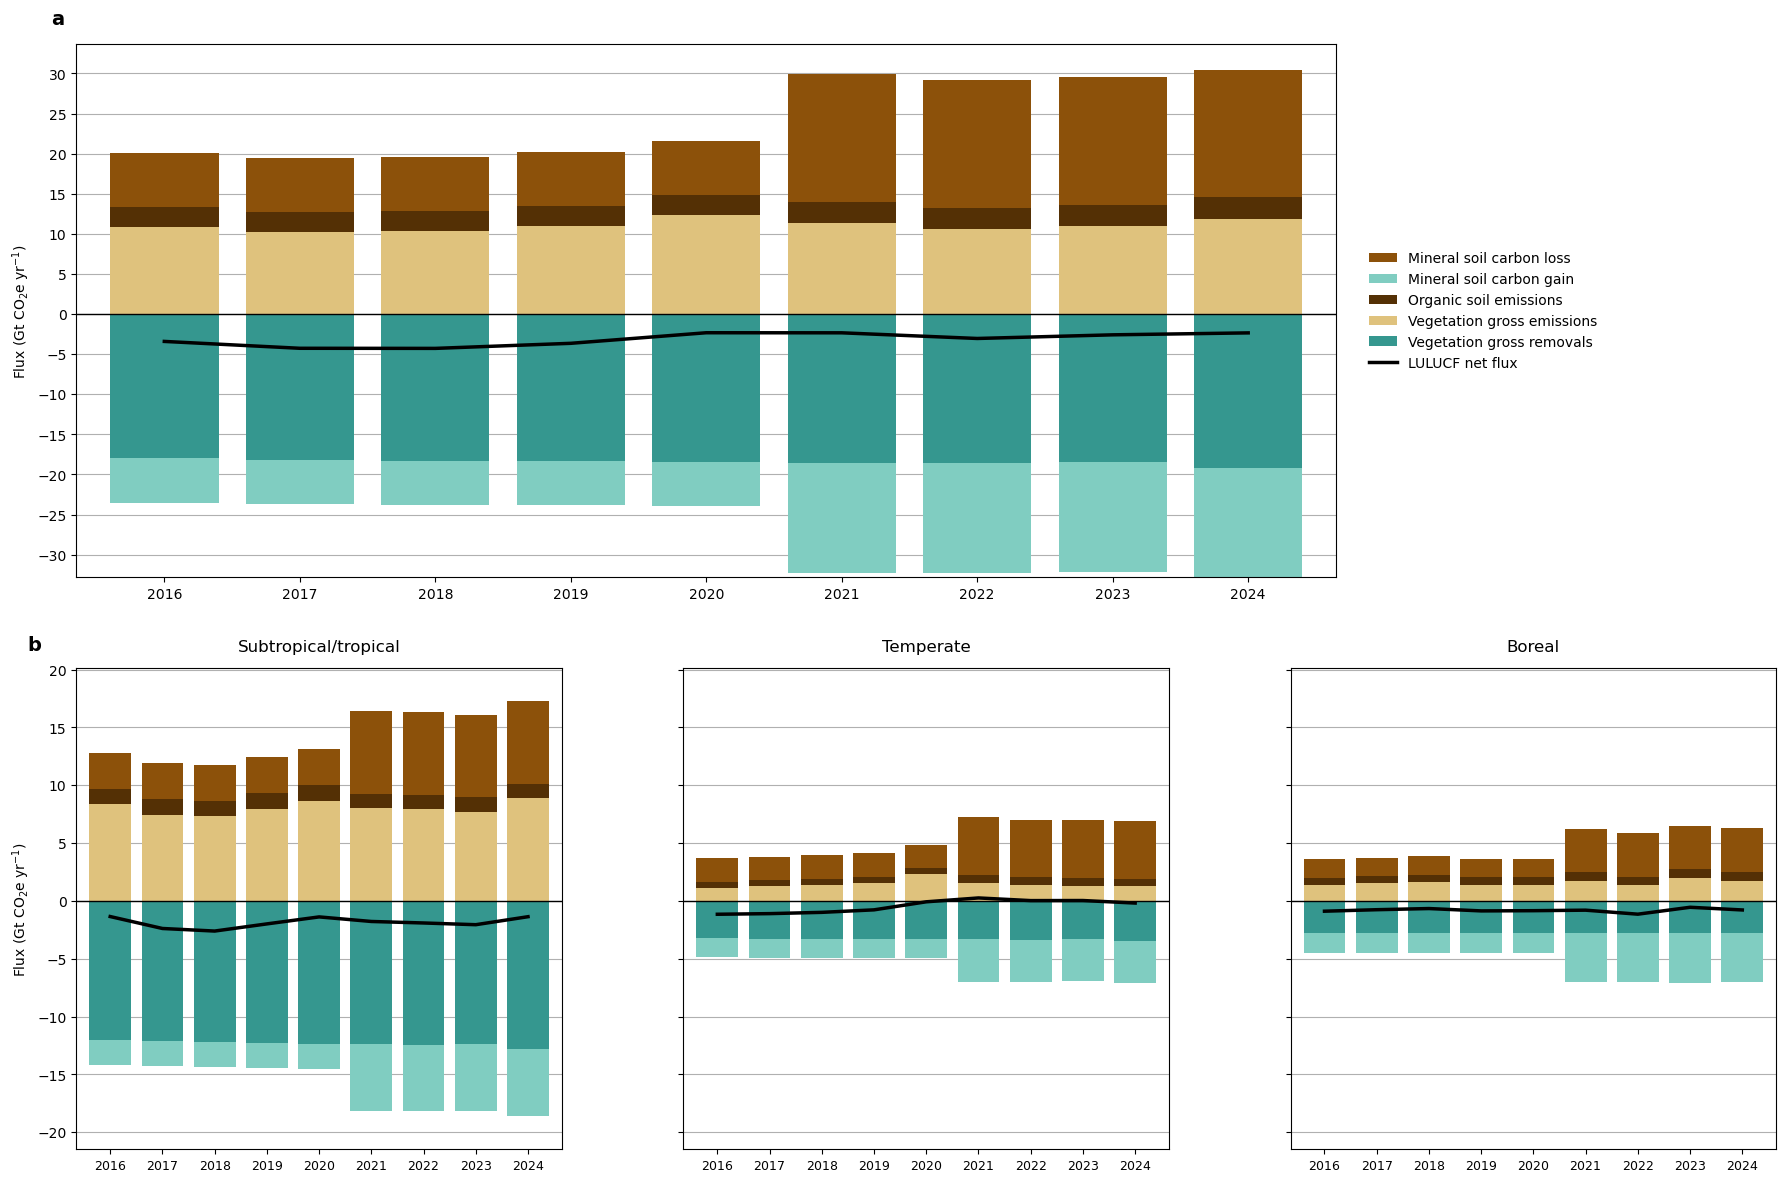

In [9]:
### Global flux timeseries (panel a) and climate-domain flux timeseries (panel b) for journal article
### Per Claude sessions 'LULUCF graph color consistency with maps' and 'LULUCF and component table creation'
### Claude said it was better to recreate the maps rather than trying to composite the global and climate domain images created above

### Global flux timeseries (panel a) and climate-domain flux timeseries (panel b) for journal article

desired_bar_order  = [COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN, COL_ORGANIC_SOIL, COL_VEG_EMIS, COL_VEG_REMOV]
desired_line_order = [COL_LULUCF_NET]
plot_cols          = desired_bar_order + desired_line_order

color_map = {
    COL_MINERAL_SOIL_LOSS: "#8c510a",
    COL_MINERAL_SOIL_GAIN: "#80cdc1",
    COL_ORGANIC_SOIL:      "#543005",
    COL_VEG_EMIS:          "#dfc27d",
    COL_VEG_REMOV:         "#35978f",
    COL_LULUCF_NET:        "#000000",
}

label_map = {
    COL_MINERAL_SOIL_LOSS: "Mineral soil carbon loss",
    COL_MINERAL_SOIL_GAIN: "Mineral soil carbon gain",
    COL_ORGANIC_SOIL:      "Organic soil emissions",
    COL_VEG_EMIS:          "Vegetation gross emissions",
    COL_VEG_REMOV:         "Vegetation gross removals",
    COL_LULUCF_NET:        "LULUCF net flux",
}

domain_order = ["Subtropical/tropical", "Temperate", "Boreal"]

domain_title_map = {
    "Subtropical/tropical": "Subtropical/tropical",
    "Temperate":            "Temperate",
    "Boreal":               "Boreal",
}

# ── Data prep ─────────────────────────────────────────────────────────────────

# Panel a: global
df_wide_a = (
    LULUCF_for_figures
    .groupby('year')[plot_cols]
    .sum()
    .rename(index=lambda y: int(y))
    .sort_index()
    / 1e9
)

# Panel b: by climate domain
df_ts_b = (
    LULUCF_for_figures[
        LULUCF_for_figures['climate_domain'].isin(domain_order)
    ]
    .groupby(['climate_domain', 'year'])[plot_cols]
    .sum()
    / 1e9
)
df_ts_b.index = df_ts_b.index.set_levels(df_ts_b.index.levels[1].astype(int), level=1)
df_ts_b = df_ts_b.sort_index()

bar_cols  = [c for c in desired_bar_order  if c in df_ts_b.columns]
line_cols = [c for c in desired_line_order if c in df_ts_b.columns]

# Shared y-limits for panel b from stacked extents
pos_sums_b = df_ts_b[bar_cols].clip(lower=0).sum(axis=1)
neg_sums_b = df_ts_b[bar_cols].clip(upper=0).sum(axis=1)
line_vals_b = df_ts_b[line_cols]
y_max_b = max(pos_sums_b.max(), line_vals_b.max().max())
y_min_b = min(neg_sums_b.min(), line_vals_b.min().min())
y_pad_b = (y_max_b - y_min_b) * 0.08
ymin_b  = y_min_b - y_pad_b
ymax_b  = y_max_b + y_pad_b

# ── Figure layout ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 13))

gs_a = GridSpec(1, 1, figure=fig,
                left=0.07, right=0.70, top=0.93, bottom=0.52)
ax_a = fig.add_subplot(gs_a[0, 0])

gs_b = GridSpec(1, 3, figure=fig,
                left=0.07, right=0.92, top=0.45, bottom=0.08,
                wspace=0.25)
ax_b0   = fig.add_subplot(gs_b[0, 0])
ax_b1   = fig.add_subplot(gs_b[0, 1], sharey=ax_b0)
ax_b2   = fig.add_subplot(gs_b[0, 2], sharey=ax_b0)
axes_b  = [ax_b0, ax_b1, ax_b2]

# ── Panel a: global ───────────────────────────────────────────────────────────

bar_cols_a  = [c for c in desired_bar_order  if c in df_wide_a.columns]
line_cols_a = [c for c in desired_line_order if c in df_wide_a.columns]
df_bars_a   = df_wide_a[bar_cols_a[::-1]]

df_bars_a.clip(lower=0).plot(kind="bar", stacked=True, ax=ax_a, width=0.8, legend=False,
                              color=[color_map[c] for c in df_bars_a.columns])
df_bars_a.clip(upper=0).plot(kind="bar", stacked=True, ax=ax_a, width=0.8, legend=False,
                              color=[color_map[c] for c in df_bars_a.columns])

x_a = np.arange(len(df_wide_a.index))
for col in line_cols_a:
    ax_a.plot(x_a, df_wide_a[col].values, linewidth=2.5,
              color=color_map.get(col, "black"), zorder=5)

ax_a.axhline(0, color="black", linewidth=1)
ax_a.grid(visible=True, axis="y")
ax_a.set_axisbelow(True)
ax_a.yaxis.set_major_locator(MultipleLocator(5))
ax_a.set_xlabel(None)
ax_a.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
ax_a.set_xticks(x_a)
ax_a.set_xticklabels(df_wide_a.index, rotation=0)

# ── Panel b: climate domains ──────────────────────────────────────────────────

for ax, domain in zip(axes_b, domain_order):
    df_wide_b = df_ts_b.loc[domain]
    df_bars_b = df_wide_b[bar_cols[::-1]]

    df_bars_b.clip(lower=0).plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
                                  color=[color_map[c] for c in df_bars_b.columns])
    df_bars_b.clip(upper=0).plot(kind="bar", stacked=True, ax=ax, width=0.8, legend=False,
                                  color=[color_map[c] for c in df_bars_b.columns])

    x = np.arange(len(df_wide_b.index))
    for col in line_cols:
        ax.plot(x, df_wide_b[col].values, linewidth=2.5,
                color=color_map.get(col, "black"), zorder=5)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_axisbelow(True)
    ax.grid(visible=True, axis="y")
    ax.set_ylim(ymin_b, ymax_b)
    ax.set_title(domain_title_map.get(domain, domain), pad=12)
    ax.set_xlabel(None)
    ax.set_xticks(x)
    ax.set_xticklabels(df_wide_b.index, rotation=0, fontsize=9)
    if ax is axes_b[0]:
        ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")

# ── Panel labels ──────────────────────────────────────────────────────────────

ax_a.text(-0.02, 1.03, "a", transform=ax_a.transAxes,
          fontsize=14, fontweight="bold", va="bottom")
axes_b[0].text(-0.10, 1.03, "b", transform=axes_b[0].transAxes,
               fontsize=14, fontweight="bold", va="bottom")

# ── Legend ────────────────────────────────────────────────────────────────────

legend_items = [
    Patch(facecolor=color_map[COL_MINERAL_SOIL_LOSS], label=label_map[COL_MINERAL_SOIL_LOSS]),
    Patch(facecolor=color_map[COL_MINERAL_SOIL_GAIN], label=label_map[COL_MINERAL_SOIL_GAIN]),
    Patch(facecolor=color_map[COL_ORGANIC_SOIL],      label=label_map[COL_ORGANIC_SOIL]),
    Patch(facecolor=color_map[COL_VEG_EMIS],          label=label_map[COL_VEG_EMIS]),
    Patch(facecolor=color_map[COL_VEG_REMOV],         label=label_map[COL_VEG_REMOV]),
    Line2D([0], [0], color=color_map[COL_LULUCF_NET], linewidth=2.5,
           label=label_map[COL_LULUCF_NET]),
]

fig.canvas.draw()
ax_a_pos = ax_a.get_position()
legend_x = ax_a_pos.x1 + 0.01
legend_y = ax_a_pos.y0 + ax_a_pos.height / 2

fig.legend(
    handles=legend_items,
    loc="center left",
    bbox_to_anchor=(legend_x, legend_y),
    frameon=False,
)

# ── Save ──────────────────────────────────────────────────────────────────────

# fig.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_global_and_climate_domain_with_legend_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### LULUCF waterfall diagram
### Made with Claude ('Create LULUCF waterfall chart') and revised with session 'LULUCF and component table creation'

# ── 0. Aggregate raw data into summary rows ──────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years    = df['year'].nunique()

# Row masks for vegetation (contextual cols are 'unassigned' on SOC/org-soil rows,
# so these filters naturally exclude non-veg rows without needing LULUCF_component)
is_tree = df['land_state_broad_class'] == 'tree'
dlc     = df['land_state_detailed_class']

VEG_NET_COLS = [COL_VEG_EMIS, COL_VEG_REMOV]
MIN_NET_COLS = [COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN]

def annual_Gt(mask, cols):
    if isinstance(cols, str):
        cols = [cols]
    cols = [c for c in cols if c in df.columns]
    return df.loc[mask, cols].sum().sum() / n_years / 1e9

def annual_Gt_all(cols):
    """Sum cols across all rows (no mask needed — zero on non-matching component rows)."""
    if isinstance(cols, str):
        cols = [cols]
    cols = [c for c in cols if c in df.columns]
    return df[cols].sum().sum() / n_years / 1e9

rows_summary = []
def add_row(section, subsection, category, val):
    rows_summary.append({
        "Section": section, "Subsection": subsection,
        "Category": category, "All_gases_Gt_CO2e_yr": val,
    })

# Vegetation (row masks work because SOC/org-soil rows have 'unassigned' land-state cols)
is_veg_tree = is_tree  # all tree rows are veg
add_row("Vegetation", "Tall vegetation", "New tree cover",
        annual_Gt(is_tree & (dlc == "tree_gain"),                                              VEG_NET_COLS))
add_row("Vegetation", "Tall vegetation", "Undisturbed tree cover (including fires)",
        annual_Gt(is_tree & (dlc == "tree_tree_undisturbed"),                                  VEG_NET_COLS))
add_row("Vegetation", "Tall vegetation", "Partially disturbed tree cover",
        annual_Gt(is_tree & dlc.isin(["tree_tree_disturbed","tree_tree_disturbed_fire_only"]), VEG_NET_COLS))
add_row("Vegetation", "Tall vegetation", "Tree cover loss",
        annual_Gt(is_tree & (dlc == "tree_loss"),                                              VEG_NET_COLS))
add_row("Vegetation", "Tall vegetation", "Total",
        annual_Gt(is_tree,                                                                      VEG_NET_COLS))
add_row("Vegetation", "Non-tall vegetation", "All classes",
        annual_Gt(df['tall_veg_type'] == 'non_tall_vegetation',                                VEG_NET_COLS))
add_row("Vegetation", "All vegetation", "Total",
        annual_Gt_all(VEG_NET_COLS))

# Organic soil — sub-components from burned/drained columns; no extraction column in data
add_row("Soil", "Organic soil", "Fire",
        annual_Gt_all('org_soil_burned_total__MgCO2e'))
add_row("Soil", "Organic soil", "Drainage",
        annual_Gt_all('org_soil_drained_total__MgCO2e'))
add_row("Soil", "Organic soil", "Total",
        annual_Gt_all(COL_ORGANIC_SOIL))

# Mineral soil
add_row("Soil", "Mineral soil", "All classes",
        annual_Gt_all(MIN_NET_COLS))

# All soil
add_row("Soil", "All soil", "Total",
        annual_Gt_all([COL_ORGANIC_SOIL, COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN]))

# LULUCF total
add_row("LULUCF", "All components", "Total",
        annual_Gt_all(COL_LULUCF_NET))

df_wf = pd.DataFrame(rows_summary)

veg_total    = df_wf.loc[df_wf["Subsection"] == "All vegetation", "All_gases_Gt_CO2e_yr"].values[0]
soil_total   = df_wf.loc[df_wf["Subsection"] == "All soil",       "All_gases_Gt_CO2e_yr"].values[0]
lulucf_total = df_wf.loc[df_wf["Section"]    == "LULUCF",         "All_gases_Gt_CO2e_yr"].values[0]

def section_subtitle(val):
    term = "net sink" if val < 0 else "net source"
    return f"({term} = {val:.3g} Gt CO₂e yr⁻¹)"

section_subtitle_map = {
    "Vegetation": section_subtitle(veg_total),
    "Soil":       section_subtitle(soil_total),
    "LULUCF":     section_subtitle(lulucf_total),
}

# ── 1. Select detail rows + LULUCF total as closing bar ─────────────────────
detail_mask = (
    ((df_wf["Subsection"] == "Tall vegetation")   & (df_wf["Category"] != "Total")) |
    ( df_wf["Subsection"] == "Non-tall vegetation")                                  |
    ((df_wf["Subsection"] == "Organic soil")       & (df_wf["Category"] != "Total")) |
    ( df_wf["Subsection"] == "Mineral soil")                                         |
    ((df_wf["Section"]    == "LULUCF")             & (df_wf["Category"] == "Total"))
)
wf = df_wf[detail_mask][["Section", "Subsection", "Category", "All_gases_Gt_CO2e_yr"]].reset_index(drop=True)
wf["is_total"] = (wf["Section"] == "LULUCF") & (wf["Category"] == "Total")

# ── 2–6. Waterfall geometry, colors, labels, plot (unchanged) ────────────────
vals    = wf["All_gases_Gt_CO2e_yr"].values.astype(float)
bottoms = np.zeros(len(vals))
running = 0.0

for i in range(len(vals)):
    if wf["is_total"].iloc[i]:
        bottoms[i] = 0.0
    else:
        bottoms[i] = running
        running   += vals[i]

SINK   = "#33cc33"
SOURCE = "#d279d2"
TOTAL  = "#616161"

colors = [
    TOTAL  if wf["is_total"].iloc[i] else
    SINK   if vals[i] < 0            else
    SOURCE
    for i in range(len(vals))
]

def make_label(row):
    if row["is_total"]:
        return "LULUCF\nTotal"
    cat, sub = row["Category"], row["Subsection"]
    short = {
        "Undisturbed tree cover (including fires)": "Undisturbed\ntree cover",
        "Partially disturbed tree cover":           "Partially\ndisturbed\ntree cover",
        "New tree cover":                           "New\ntree cover",
        "Tree cover loss":                          "Tree cover\nloss",
        "Fire":                                     "Organic soil\nfire",
        "Drainage":                                 "Organic soil\ndrainage",
    }
    if cat == "All classes":
        return "Short veg. &\ncropland" if sub == "Non-tall vegetation" else sub
    if sub == "Organic soil" and cat == "Total":
        return "Organic\nsoil"
    return short.get(cat, cat)

labels = [make_label(row) for _, row in wf.iterrows()]

sections = wf["Section"].values
section_groups = {}
for i, s in enumerate(sections):
    section_groups.setdefault(s, []).append(i)

fig, ax = plt.subplots(figsize=(14, 7))

bar_bottoms = np.where(vals < 0, bottoms + vals, bottoms)
bar_heights = np.abs(vals)

bars = ax.bar(
    range(len(vals)),
    bar_heights,
    bottom=bar_bottoms,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.65,
)

ax.grid(False)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

for i in range(len(vals) - 1):
    if not wf["is_total"].iloc[i] and not wf["is_total"].iloc[i + 1]:
        y = bottoms[i] + vals[i]
        ax.plot([i + 0.33, i + 0.67], [y, y],
                color="grey", linewidth=0.8, linestyle="--", alpha=0.6)

SMALL_BAR = 0.6
for i, (bar, val) in enumerate(zip(bars, vals)):
    label_text = f"{val:+.2g}"
    if bar.get_height() < SMALL_BAR:
        if val >= 0:
            y_pos, va = bar.get_y() + bar.get_height() + 0.15, "bottom"
        else:
            y_pos, va = bar.get_y() - 0.15, "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label_text,
                ha="center", va=va, fontsize=12, color="black", fontweight="bold")
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2, label_text,
                ha="center", va="center", fontsize=12, color="white", fontweight="bold")

ax.axhline(0, color="black", linewidth=0.9)

for i in range(1, len(sections)):
    if sections[i] != sections[i - 1]:
        ax.axvline(i - 0.5, color="#555555", linewidth=1.2, linestyle="-", alpha=0.35)

ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, rotation=0, ha="center")
ax.tick_params(axis="x", labelsize=10)
ax.set_title("LULUCF GHG flux components (all GHGs, average for 2016-2024)", pad=20)

ax.yaxis.set_major_locator(MultipleLocator(2.5))
ax.set_yticklabels([])
ax.set_ylabel("")

trans = blended_transform_factory(ax.transAxes, ax.transData)
ax.annotate("", xy=(-0.03, 0), xytext=(-0.03, -2.5),
            xycoords=trans, textcoords=trans,
            annotation_clip=False,
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.0))
txt = ax.text(-0.05, -1.25, "2.5 Gt\nCO₂e yr⁻¹",
              transform=trans, ha="right", va="center", fontsize=9)
txt.set_clip_on(False)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([np.mean(idxs) for idxs in section_groups.values()])
ax2.set_xticklabels(list(section_groups.keys()), fontweight="bold")
ax2.tick_params(length=0, pad=18)
ax2.grid(False)

trans2 = blended_transform_factory(ax2.transData, ax2.transAxes)
for section, idxs in section_groups.items():
    t = ax2.text(
        np.mean(idxs), 1.01,
        section_subtitle_map[section],
        transform=trans2,
        ha="center", va="bottom",
        fontsize=9,
        clip_on=False,
    )

ax.spines["top"].set_visible(False)
ax2.spines["bottom"].set_visible(False)

ax.legend(
    handles=[
        mpatches.Patch(color=SINK,   label="Sink (−)"),
        mpatches.Patch(color=SOURCE, label="Source (+)"),
        mpatches.Patch(color=TOTAL,  label="Net sink"),
    ],
    loc="lower right", fontsize=9
)

plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_global_waterfall_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()
df_wf

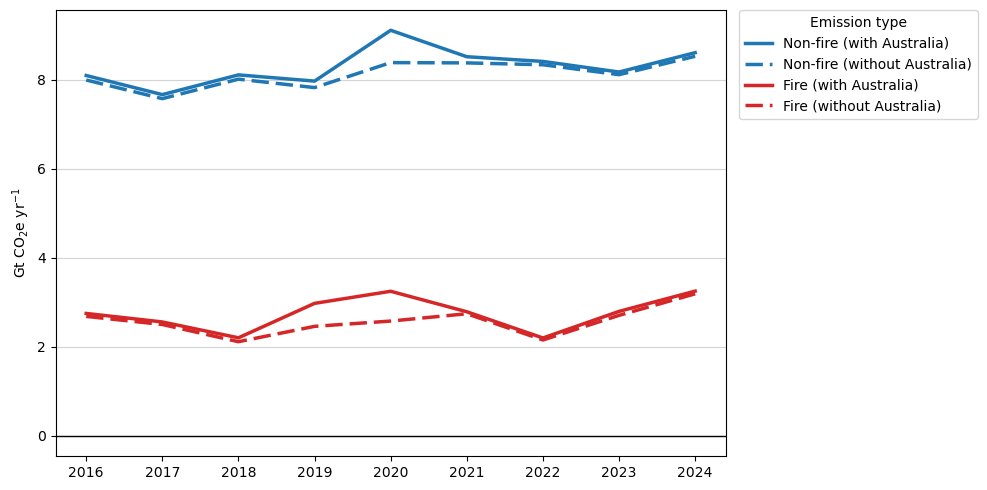

In [10]:
### Global vegetation gross emissions timeseries by fire vs. non-fire, with and without Australia (single panel)
### Per Claude sessions "Create global emissions timeseries graph" and "LULUCF and component table creation"

# ---- Setup ----
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)

# ---- Classify fire vs non-fire on land_state_node ----
# land_state_node is float in the wide table; 'unassigned' rows (SOC/org-soil)
# are handled by the except branch and contribute 0 to COL_VEG_EMIS anyway
def classify_fire(x):
    try:
        return "Fire" if re.search(r"9(0*)$", str(int(float(x)))) else "Non-fire"
    except (ValueError, TypeError):
        return "Non-fire"

df["fire_class"] = df["land_state_node"].apply(classify_fire)

# ---- Aggregate WITH Australia ----
df_with_aus = (
    df
    .groupby(["fire_class", "year"], as_index=False)[COL_VEG_EMIS]
    .sum()
    .rename(columns={COL_VEG_EMIS: "flux_Mg_CO2e_yr"})
)
df_with_aus["Australia_group"] = "with Australia"

# ---- Aggregate WITHOUT Australia ----
df_without_aus = (
    df[df["country_name"] != "Australia"]
    .groupby(["fire_class", "year"], as_index=False)[COL_VEG_EMIS]
    .sum()
    .rename(columns={COL_VEG_EMIS: "flux_Mg_CO2e_yr"})
)
df_without_aus["Australia_group"] = "without Australia"

# ---- Combine and convert to Gt ----
df_emis_ts = pd.concat([df_with_aus, df_without_aus], ignore_index=True)
df_emis_ts["value_Gt"] = df_emis_ts["flux_Mg_CO2e_yr"] / 1e9
df_emis_ts["series"]   = df_emis_ts["fire_class"] + " (" + df_emis_ts["Australia_group"] + ")"

# ---- Plot ----
series_order = [
    "Non-fire (with Australia)",
    "Non-fire (without Australia)",
    "Fire (with Australia)",
    "Fire (without Australia)",
]

series_palette = {
    "Non-fire (with Australia)":    "#1f77b4",
    "Non-fire (without Australia)": "#1f77b4",
    "Fire (with Australia)":        "#d62728",
    "Fire (without Australia)":     "#d62728",
}

series_dashes = {
    "Non-fire (with Australia)":    "",
    "Non-fire (without Australia)": (5, 2),
    "Fire (with Australia)":        "",
    "Fire (without Australia)":     (5, 2),
}

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=df_emis_ts,
    x="year",
    y="value_Gt",
    hue="series",
    style="series",
    hue_order=series_order,
    style_order=series_order,
    palette=series_palette,
    dashes=series_dashes,
    linewidth=2.5,
)

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel(None)
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")

ax.legend(
    title="Emission type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/veg_emis_timeseries_fire_Australia_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

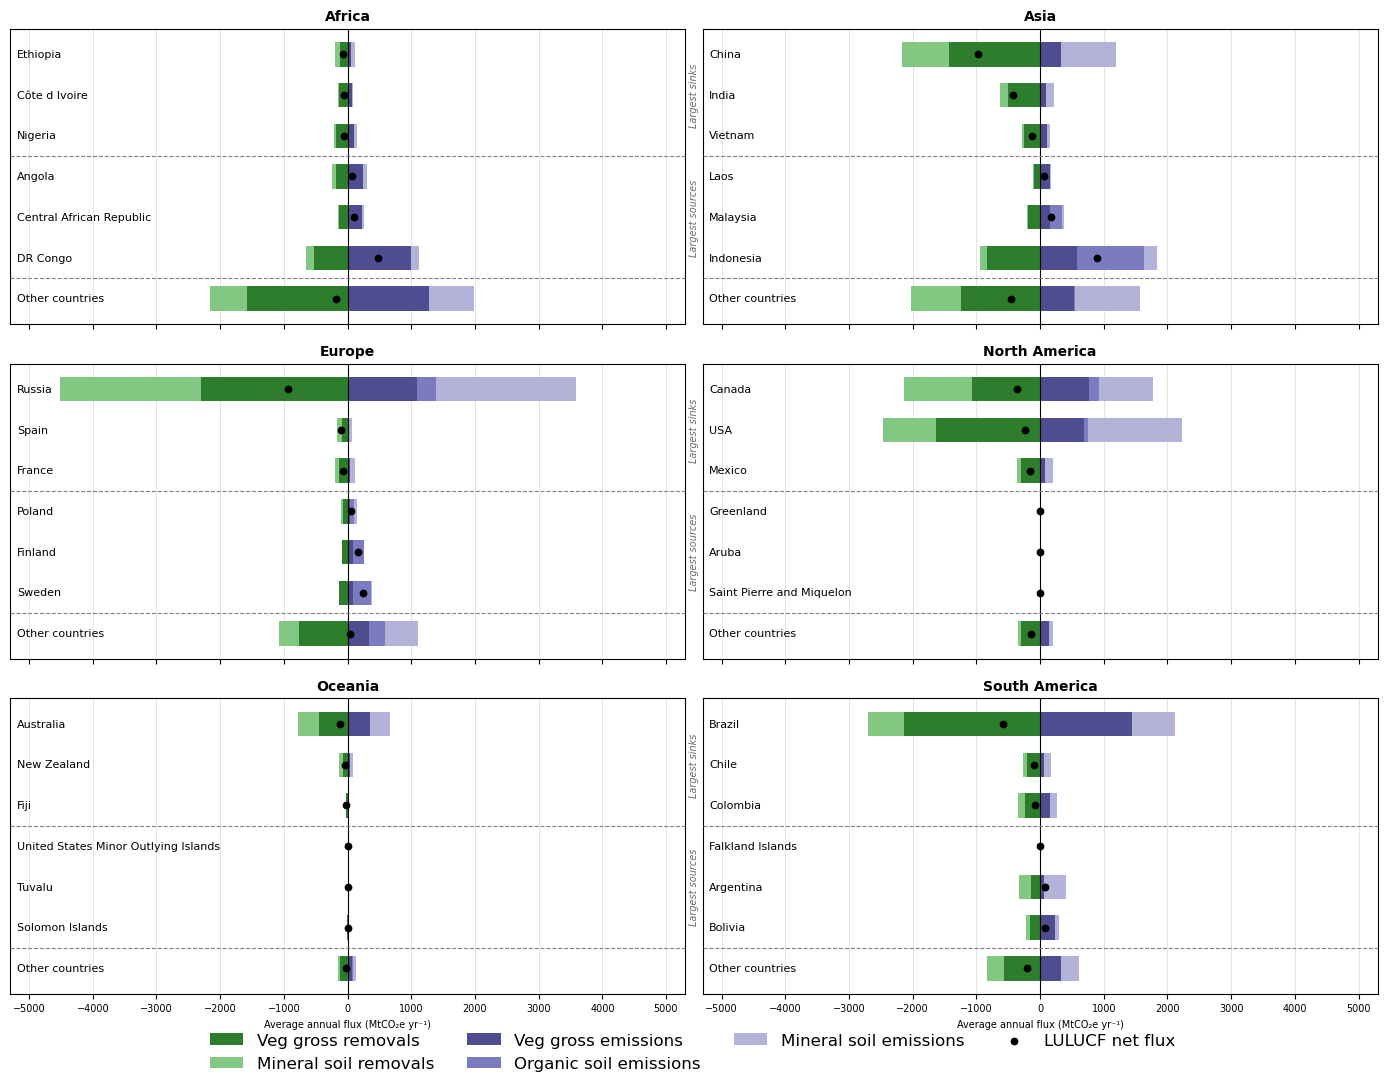

In [11]:
### Bar graphs of countries with largest net sources and sinks by continent
### Country-level gross/net LULUCF fluxes by region (horizontal stacked bars, net as dot)
### Top 3 net emitters + top 3 net removers per region + Other countries
### From Claude sessions 'Bar graph of countries with largest net sources-sinks' and 'LULUCF and component table creation'

### Bar graphs of countries with largest net sources and sinks by continent

# ── Setup ───────────────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()

MIN_SOIL_LOSS = COL_MINERAL_SOIL_LOSS   # 'SOC_loss__mineral_soil_extent__0-30cm_MgCO2'
MIN_SOIL_GAIN = COL_MINERAL_SOIL_GAIN   # 'SOC_gain__mineral_soil_extent__0-30cm_MgCO2'

# ── Annual average flux per country ─────────────────────────────────────────
agg_cols = [COL_VEG_EMIS, COL_VEG_REMOV, MIN_SOIL_LOSS, MIN_SOIL_GAIN,
            COL_ORGANIC_SOIL, COL_LULUCF_NET]

df_wide = (
    df
    .groupby(["region_L1", "country_name"], as_index=False)[agg_cols]
    .sum()
)
for col in agg_cols:
    df_wide[col] = df_wide[col] / n_years / 1e6   # Mg → Mt annual average

df_wide["gross_emis_Mt"]     = df_wide[COL_VEG_EMIS] + df_wide[COL_ORGANIC_SOIL] + df_wide[MIN_SOIL_LOSS]
df_wide["gross_remov_Mt"]    = df_wide[COL_VEG_REMOV]
df_wide["min_soil_remov_Mt"] = df_wide[MIN_SOIL_GAIN]
df_wide["net_Mt"]            = df_wide[COL_LULUCF_NET]

# ── Drop Antarctica and unassigned regions ───────────────────────────────────
REGIONS_TO_DROP = {"Antarctica", "Unassigned", "unassigned"}
df_wide = df_wide[~df_wide["region_L1"].isin(REGIONS_TO_DROP)].copy()

# ── Country selection ────────────────────────────────────────────────────────
def select_countries(group, region_name):
    top_emis  = group.nlargest(3,  "net_Mt")["country_name"].tolist()
    top_remov = group.nsmallest(3, "net_Mt")["country_name"].tolist()
    featured  = list(dict.fromkeys(top_emis + top_remov))

    rows = []
    for cname in featured:
        r = group[group["country_name"] == cname].iloc[0].copy()
        r["region_L1"]      = region_name
        r["featured_group"] = "source" if cname in top_emis else "sink"
        rows.append(r)

    other_mask = ~group["country_name"].isin(featured)
    if other_mask.any():
        other = group[other_mask].sum(numeric_only=True)
        other["country_name"]   = "Other countries"
        other["region_L1"]      = region_name
        other["featured_group"] = "other"
        rows.append(other)

    return pd.DataFrame(rows)

df_plot = (
    df_wide
    .groupby("region_L1", group_keys=False)
    .apply(lambda grp: select_countries(grp, grp.name), include_groups=False)
    .reset_index(drop=True)
)

# ── Colour / style constants ─────────────────────────────────────────────────
COLOR_VEG_EMIS  = "#4d4d8f"
COLOR_ORG_EMIS  = "#7b7bbf"
COLOR_MIN_EMIS  = "#b3b3d9"
COLOR_VEG_REMOV = "#2d7d2d"
COLOR_MIN_REMOV = "#82c882"
DOT_COLOR       = "black"
DOT_SIZE        = 21
VEG_DOT_SIZE    = DOT_SIZE * 0.7

emis_max  = (df_plot[COL_VEG_EMIS] + df_plot[COL_ORGANIC_SOIL] + df_plot[MIN_SOIL_LOSS]).max()
remov_max = (df_plot["gross_remov_Mt"] + df_plot["min_soil_remov_Mt"]).abs().max()
axis_max  = int(np.ceil(max(emis_max, remov_max) / 1000) * 1000)
X_TICKS   = list(range(-axis_max, axis_max + 1, 1000))

LEGEND_ORDER = [
    "Veg gross removals",
    "Mineral soil removals",
    "Veg gross emissions",
    "Organic soil emissions",
    "Mineral soil emissions",
    "LULUCF net flux",
]

# ── Build the figure ─────────────────────────────────────────────────────────
regions   = sorted(df_plot["region_L1"].unique())
n_regions = len(regions)
ncols = 2
nrows = (n_regions + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5), squeeze=False)

x_pad = axis_max * 0.06
xlim  = (-axis_max - x_pad, axis_max + x_pad)

_row_mids = {}

for idx, region in enumerate(regions):
    row = idx // ncols
    col = idx % ncols
    ax  = axes[row][col]

    df_r      = df_plot[df_plot["region_L1"] == region].copy()
    other_row = df_r[df_r["featured_group"] == "other"]
    emis_r    = df_r[df_r["featured_group"] == "source"].sort_values("net_Mt", ascending=False)
    remov_r   = df_r[df_r["featured_group"] == "sink"].sort_values("net_Mt", ascending=False)
    feature_r = pd.concat([emis_r, remov_r], ignore_index=True)
    df_r      = pd.concat([other_row, feature_r], ignore_index=True)

    countries = df_r["country_name"].tolist()
    y = np.arange(len(countries))

    veg_e    = df_r[COL_VEG_EMIS].values
    org_e    = df_r[COL_ORGANIC_SOIL].values
    min_loss = df_r[MIN_SOIL_LOSS].values
    veg_r    = df_r["gross_remov_Mt"].values
    min_gain = df_r["min_soil_remov_Mt"].values

    ax.barh(y, veg_e,                      height=0.6, color=COLOR_VEG_EMIS,  label="Veg gross emissions")
    ax.barh(y, org_e,  left=veg_e,         height=0.6, color=COLOR_ORG_EMIS,  label="Organic soil emissions")
    ax.barh(y, min_loss, left=veg_e+org_e, height=0.6, color=COLOR_MIN_EMIS,  label="Mineral soil emissions")
    ax.barh(y, veg_r,                      height=0.6, color=COLOR_VEG_REMOV, label="Veg gross removals")
    ax.barh(y, min_gain, left=veg_r,       height=0.6, color=COLOR_MIN_REMOV, label="Mineral soil removals")
    ax.scatter(df_r["net_Mt"].values,     y, color=DOT_COLOR, zorder=5, s=DOT_SIZE,     label="LULUCF net flux")

    n_emis = len(emis_r)
    if n_emis > 0 and len(remov_r) > 0:
        ax.axhline(y=n_emis + 0.5, color="gray", linestyle="--", linewidth=0.8, zorder=3)
    if n_emis > 0:
        ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, zorder=3)
    if col == 0:
        _row_mids[row] = (
            (1 + n_emis) / 2 if n_emis > 0 else None,
            n_emis + 0.5 + len(remov_r) / 2 if len(remov_r) > 0 else None,
            ax,
        )

    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.tick_params(axis="y", left=False, right=False)
    x_label = xlim[0] + (xlim[1] - xlim[0]) * 0.01
    for yi, name in zip(y, countries):
        ax.text(x_label, yi, name, ha="left", va="center", fontsize=8, clip_on=True)
    ax.set_xlim(xlim)
    ax.set_xticks(X_TICKS)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(region, fontsize=10, fontweight="bold")
    ax.grid(axis="x", linewidth=0.5, alpha=0.5, which="major")
    ax.set_axisbelow(True)

    if row == nrows - 1:
        ax.set_xlabel("Average annual flux (MtCO₂e yr⁻¹)", fontsize=7)
        ax.tick_params(axis="x", labelsize=7)
    else:
        ax.set_xlabel(None)
        ax.tick_params(axis="x", labelbottom=False)

for idx in range(n_regions, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

# ── Legend ───────────────────────────────────────────────────────────────────
handles, labels = axes[0][0].get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[l] for l in LEGEND_ORDER if l in label_to_handle]
ordered_labels  = [l for l in LEGEND_ORDER if l in label_to_handle]

fig.legend(
    ordered_handles, ordered_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()

for row_idx, (y_src, y_snk, ax_left) in _row_mids.items():
    if not axes[row_idx][1].get_visible():
        continue
    pos_l = ax_left.get_position()
    pos_r = axes[row_idx][1].get_position()
    x_mid = (pos_l.x1 + pos_r.x0) / 2
    for y_dat, lbl in [(y_src, "Largest sources"), (y_snk, "Largest sinks")]:
        if y_dat is None:
            continue
        _, y_fig = fig.transFigure.inverted().transform(
            ax_left.transData.transform([0, y_dat])
        )
        fig.text(x_mid, y_fig, lbl, ha="center", va="center",
                 fontsize=7, color="dimgray", style="italic", rotation=90)

# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_region_country_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

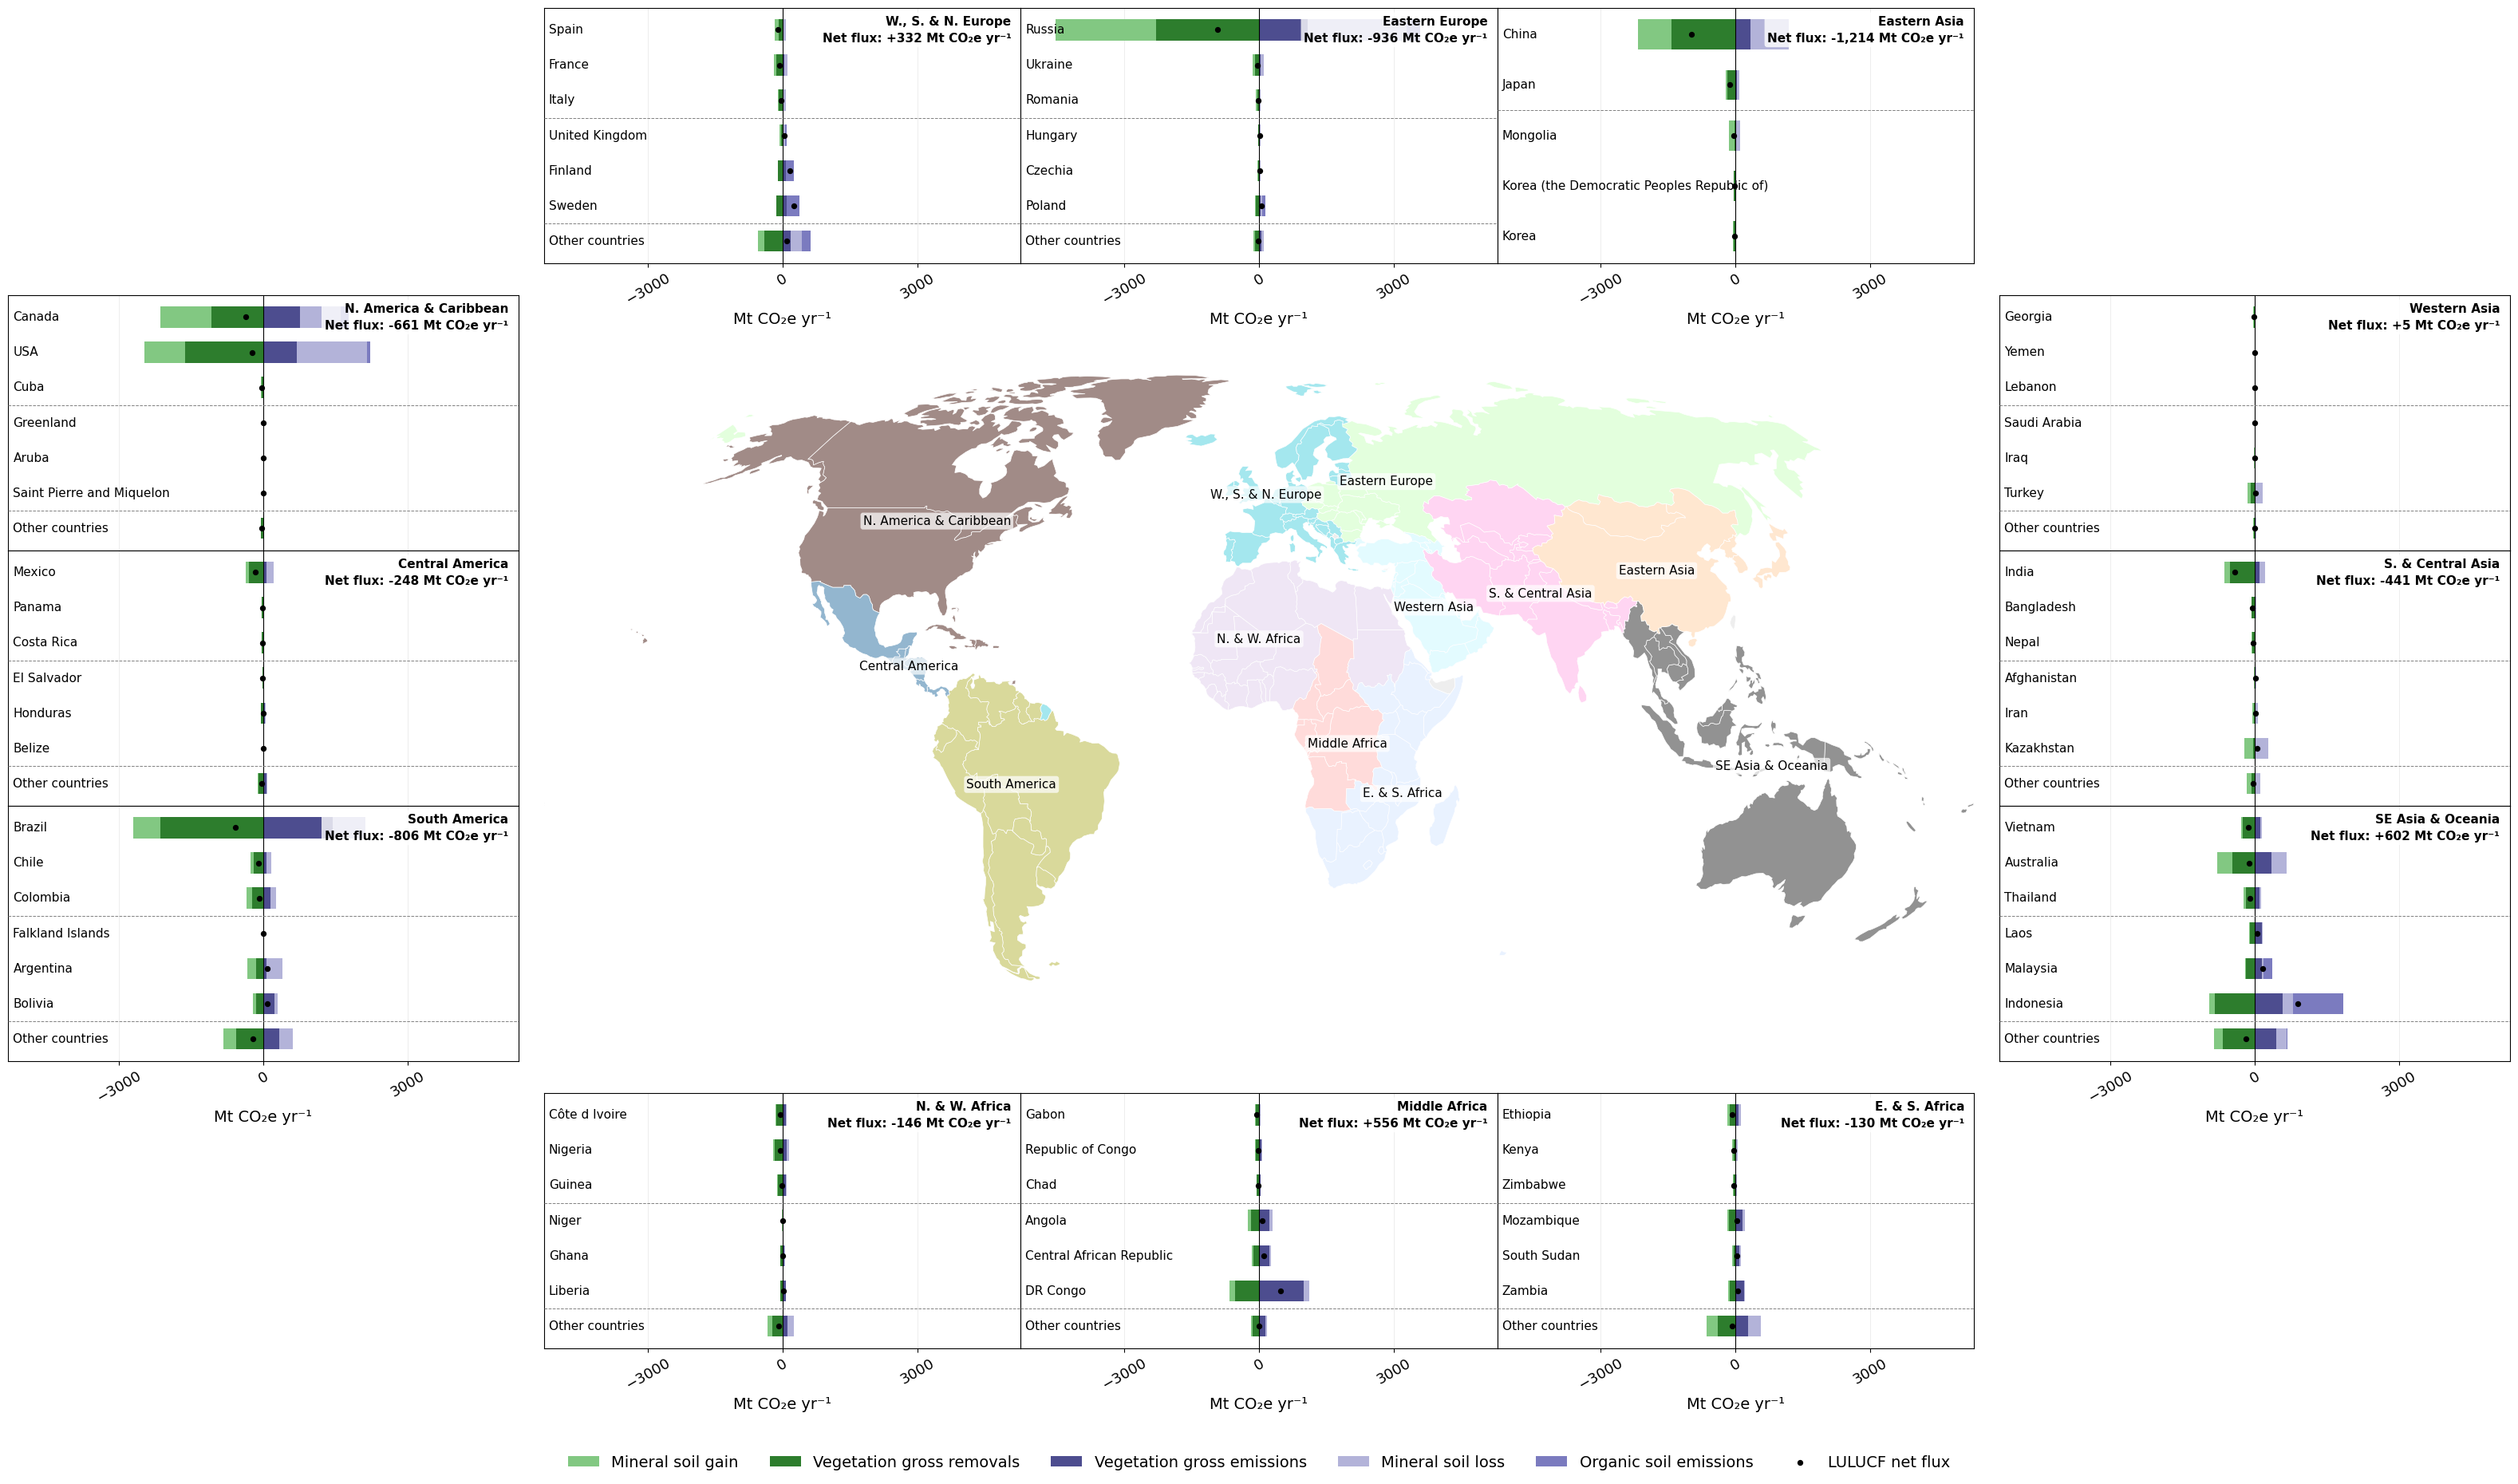

,map_region,country_name,featured_group,net_Mt,gross_removals__all_C_pools__MgCO2,gross_emissions__all_C_pools__all_gases__MgCO2e,organic_soil_emis_total__MgCO2e,SOC_loss__mineral_soil_extent__0-30cm_MgCO2,SOC_gain__mineral_soil_extent__0-30cm_MgCO2
0,Central America,Belize,source,-2.1,-6.7,3.8,0.0,2.0,-1.4
1,Central America,Honduras,source,-3.0,-44.2,38.4,0.0,9.4,-6.6
2,Central America,El Salvador,source,-8.8,-9.9,1.1,0.0,1.3,-1.3
3,Central America,Mexico,sink,-161.2,-301.5,73.7,0.1,133.8,-67.2
4,Central America,Panama,sink,-21.5,-31.9,10.5,0.0,6.7,-6.9
5,Central America,Costa Rica,sink,-21.2,-26.0,5.1,0.0,4.6,-4.9
6,Central America,Other countries,other,-29.9,-94.2,63.2,0.1,17.6,-16.5
7,E. & S. Africa,Zambia,source,39.7,-135.2,183.3,0.0,29.7,-38.1
8,E. & S. Africa,South Sudan,source,35.0,-49.0,84.8,0.0,25.4,-26.1
9,E. & S. Africa,Mozambique,source,22.5,-146.6,159.1,0.0,39.3,-29.3


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# Combined LULUCF figure v6
# ═══════════════════════════════════════════════════════════════════════════════
import colorsys
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Point

# ── Region merging ────────────────────────────────────────────────────────────
REGION_MERGE = {
    "Northern America":   "N. America & Caribbean",
    "Caribbean":          "N. America & Caribbean",
    "Northern Europe":    "W., S. & N. Europe",
    "Western Europe":     "W., S. & N. Europe",
    "Southern Europe":    "W., S. & N. Europe",
    "Northern Africa":    "N. & W. Africa",
    "Western Africa":     "N. & W. Africa",
    "Eastern Africa":     "E. & S. Africa",
    "Southern Africa":    "E. & S. Africa",
    "Central Asia":       "S. & Central Asia",
    "Southern Asia":      "S. & Central Asia",
    "South-eastern Asia": "SE Asia & Oceania",
    "Oceania":            "SE Asia & Oceania",
}

# ── Data prep ─────────────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df["year"] = df["year"].astype(int)
n_years = df["year"].nunique()

df["map_region"] = np.where(
    df["region_L1"] == "Oceania", "Oceania", df["region_L2_L3"]
)
df["map_region"] = df["map_region"].replace(REGION_MERGE)
df = df[
    df["map_region"].notna()
    & ~df["map_region"].isin(["Antarctica", "Unassigned", "unassigned"])
].copy()

agg_cols = [COL_VEG_EMIS, COL_VEG_REMOV, COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN,
            COL_ORGANIC_SOIL, COL_LULUCF_NET]
df_wide = (
    df
    .groupby(["map_region", "country_name"], as_index=False)[agg_cols]
    .sum()
)
for col in agg_cols:
    df_wide[col] = df_wide[col] / n_years / 1e6

df_wide["gross_remov_Mt"]    = df_wide[COL_VEG_REMOV]
df_wide["min_soil_remov_Mt"] = df_wide[COL_MINERAL_SOIL_GAIN]
df_wide["net_Mt"]            = df_wide[COL_LULUCF_NET]

# Regional totals for panel labels (all countries, before selection)
regional_net = df_wide.groupby("map_region")["net_Mt"].sum()

# ── Country selection ─────────────────────────────────────────────────────────
def select_countries(group, region_name):
    top_emis  = group.nlargest(3,  "net_Mt")["country_name"].tolist()
    top_remov = group.nsmallest(3, "net_Mt")["country_name"].tolist()
    featured  = list(dict.fromkeys(top_emis + top_remov))
    rows = []
    for cname in featured:
        r = group[group["country_name"] == cname].iloc[0].copy()
        r["map_region"]     = region_name
        r["featured_group"] = "source" if cname in top_emis else "sink"
        rows.append(r)
    other_mask = ~group["country_name"].isin(featured)
    if other_mask.any():
        other = group[other_mask].sum(numeric_only=True)
        other["country_name"]   = "Other countries"
        other["map_region"]     = region_name
        other["featured_group"] = "other"
        rows.append(other)
    return pd.DataFrame(rows)

df_plot = (
    df_wide
    .groupby("map_region", group_keys=False)
    .apply(lambda grp: select_countries(grp, grp.name), include_groups=False)
    .reset_index(drop=True)
)

# ── Colours & axis limits ─────────────────────────────────────────────────────
COLOR_VEG_EMIS  = "#4d4d8f"
COLOR_ORG_EMIS  = "#7b7bbf"
COLOR_MIN_EMIS  = "#b3b3d9"
COLOR_VEG_REMOV = "#2d7d2d"
COLOR_MIN_REMOV = "#82c882"
DOT_COLOR       = "black"
DOT_SIZE        = 18

emis_max = (df_plot[COL_VEG_EMIS] + df_plot[COL_ORGANIC_SOIL] + df_plot[COL_MINERAL_SOIL_LOSS]).max()
remov_max = (df_plot["gross_remov_Mt"] + df_plot["min_soil_remov_Mt"]).abs().max()
axis_max  = int(np.ceil(max(emis_max, remov_max) / 1000) * 1000)
x_pad     = axis_max * 0.06
xlim      = (-axis_max - x_pad, axis_max + x_pad)

LEGEND_ORDER = [
    "Mineral soil gain", "Vegetation gross removals",
    "Vegetation gross emissions", "Mineral soil loss",
    "Organic soil emissions", "LULUCF net flux",
]

# ── Map data ──────────────────────────────────────────────────────────────────
ROBINSON_CRS = cn.Robinson_crs

def _iso_to_map_region(iso):
    if not isinstance(iso, str) or iso == "-99":
        return None
    if cn.iso_to_region_UN_geoscheme_L1.get(iso) == "Oceania":
        return "Oceania"
    region = cn.iso_to_region_UN_geoscheme_L2_L3.get(iso)
    if region == "Eastern Europe" and iso in {"KOR", "PRK"}:
        return "Eastern Asia"
    return region

try:
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
except AttributeError:
    world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
    world = world.rename(columns={"ISO_A3_EH": "iso_a3"})

world = world[world["iso_a3"] != "ATA"].copy()
world["map_region"] = world["iso_a3"].map(_iso_to_map_region).replace(REGION_MERGE)

all_regions_sorted = sorted([
    "W., S. & N. Europe", "Eastern Europe",
    "N. & W. Africa", "Middle Africa", "E. & S. Africa",
    "N. America & Caribbean", "Central America", "South America",
    "Eastern Asia", "Western Asia", "S. & Central Asia", "SE Asia & Oceania",
])

def _desaturate(hex_color, sat_factor=0.35, val_boost=1.15):
    r, g, b = mcolors.to_rgb(hex_color)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    r2, g2, b2 = colorsys.hsv_to_rgb(h, s * sat_factor, min(v * val_boost, 1.0))
    return mcolors.to_hex((r2, g2, b2))

_tab20 = plt.colormaps.get_cmap("tab20").resampled(len(all_regions_sorted))
REGION_COLORS = {
    r: _desaturate(mcolors.to_hex(_tab20(i)))
    for i, r in enumerate(all_regions_sorted)
}

world["map_color"] = world["map_region"].map(lambda r: REGION_COLORS.get(r, "#eeeeee"))
world = world.to_crs(ROBINSON_CRS)

LABEL_POSITIONS_WGS84 = {
    "W., S. & N. Europe":     (  2,  52),
    "Eastern Europe":         ( 38,  55),
    "N. & W. Africa":         (  0,  20),
    "Middle Africa":          ( 22,  -3),
    "E. & S. Africa":         ( 36, -14),
    "N. America & Caribbean": (-90,  46),
    "Central America":        (-88,  14),
    "South America":          (-62, -12),
    "Eastern Asia":           (105,  35),
    "Western Asia":           ( 45,  27),
    "S. & Central Asia":      ( 73,  30),
    "SE Asia & Oceania":      (128,  -8),
}
_label_gdf = gpd.GeoDataFrame(
    {"region": list(LABEL_POSITIONS_WGS84.keys())},
    geometry=[Point(lon, lat) for lon, lat in LABEL_POSITIONS_WGS84.values()],
    crs="EPSG:4326",
).to_crs(ROBINSON_CRS)
LABEL_POS_ROB = {
    row["region"]: (row.geometry.x, row.geometry.y)
    for _, row in _label_gdf.iterrows()
}

# ── Panel layout ──────────────────────────────────────────────────────────────
_ph    = 0.16
_pw_tb = 0.56 / 3   # ≈ 0.1867
_pw_lr = 0.20

_map_bot = 0.28
_map_top = _map_bot + 3 * _ph   # 0.76
MAP_BOUNDS = [0.22, _map_bot, 0.56, _map_top - _map_bot]

_top_bot = _map_top + 0.02      # 0.78
_bot_bot = _map_bot - _ph - 0.02   # 0.10

PANEL_LAYOUT = {
    # Top strip
    "W., S. & N. Europe":     [0.220,             _top_bot, _pw_tb, _ph],
    "Eastern Europe":         [0.220 +   _pw_tb,  _top_bot, _pw_tb, _ph],
    "Eastern Asia":           [0.220 + 2*_pw_tb,  _top_bot, _pw_tb, _ph],
    # Bottom strip
    "N. & W. Africa":         [0.220,             _bot_bot, _pw_tb, _ph],
    "Middle Africa":          [0.220 +   _pw_tb,  _bot_bot, _pw_tb, _ph],
    "E. & S. Africa":         [0.220 + 2*_pw_tb,  _bot_bot, _pw_tb, _ph],
    # Left column (N → S)
    "N. America & Caribbean": [0.01, _map_bot + 2*_ph, _pw_lr, _ph],
    "Central America":        [0.01, _map_bot +   _ph, _pw_lr, _ph],
    "South America":          [0.01, _map_bot,          _pw_lr, _ph],
    # Right column (N → S)
    "Western Asia":           [0.79, _map_bot + 2*_ph, _pw_lr, _ph],
    "S. & Central Asia":      [0.79, _map_bot +   _ph, _pw_lr, _ph],
    "SE Asia & Oceania":      [0.79, _map_bot,          _pw_lr, _ph],
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(32, 20))

ax_map = fig.add_axes(MAP_BOUNDS)
ax_map.set_aspect("equal")
ax_map.set_axis_off()

panel_axes = {
    region: fig.add_axes([l, b, w, h])
    for region, (l, b, w, h) in PANEL_LAYOUT.items()
}

# ── Draw map ──────────────────────────────────────────────────────────────────
bounds = world.total_bounds
ax_map.set_xlim(bounds[0], bounds[2])
ax_map.set_ylim(bounds[1], bounds[3])
world.plot(ax=ax_map, color=world["map_color"].tolist(),
           edgecolor="white", linewidth=0.5, zorder=1)
for region, (rx, ry) in LABEL_POS_ROB.items():
    ax_map.text(rx, ry, region, ha="center", va="center",
                fontsize=11, zorder=7, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          alpha=0.70, edgecolor="none"))

# ── Bar chart panels ──────────────────────────────────────────────────────────
for region, ax in panel_axes.items():
    df_r = df_plot[df_plot["map_region"] == region].copy()
    if df_r.empty:
        ax.set_visible(False)
        continue

    other_row = df_r[df_r["featured_group"] == "other"]
    emis_r    = df_r[df_r["featured_group"] == "source"].sort_values("net_Mt", ascending=False)
    remov_r   = df_r[df_r["featured_group"] == "sink"].sort_values("net_Mt", ascending=False)
    df_r      = pd.concat([other_row, emis_r, remov_r], ignore_index=True)

    countries = df_r["country_name"].tolist()
    y         = np.arange(len(countries))

    veg_e    = df_r[COL_VEG_EMIS].values
    org_e    = df_r[COL_ORGANIC_SOIL].values
    min_loss = df_r[COL_MINERAL_SOIL_LOSS].values
    veg_r    = df_r["gross_remov_Mt"].values
    min_gain = df_r["min_soil_remov_Mt"].values

    ax.barh(y, veg_r,                           height=0.6, color=COLOR_VEG_REMOV, label="Vegetation gross removals")
    ax.barh(y, min_gain, left=veg_r,            height=0.6, color=COLOR_MIN_REMOV, label="Mineral soil gain")
    ax.barh(y, veg_e,                           height=0.6, color=COLOR_VEG_EMIS,  label="Vegetation gross emissions")
    ax.barh(y, min_loss, left=veg_e,            height=0.6, color=COLOR_MIN_EMIS,  label="Mineral soil loss")
    ax.barh(y, org_e,    left=veg_e + min_loss, height=0.6, color=COLOR_ORG_EMIS,  label="Organic soil emissions")
    ax.scatter(df_r["net_Mt"].values, y, color=DOT_COLOR, zorder=5,
               s=DOT_SIZE, label="LULUCF net flux")

    # Separator lines — offsets depend on whether an Other countries row exists
    n_other = len(other_row)
    n_emis  = len(emis_r)
    n_remov = len(remov_r)
    if n_other > 0 and n_emis > 0:
        ax.axhline(y=n_other - 0.5,
                   color="gray", linestyle="--", linewidth=0.7, zorder=3)
    if n_emis > 0 and n_remov > 0:
        ax.axhline(y=n_other + n_emis - 0.5,
                   color="gray", linestyle="--", linewidth=0.7, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.tick_params(axis="y", left=False, right=False)
    x_lbl = xlim[0] + (xlim[1] - xlim[0]) * 0.01
    for yi, name in zip(y, countries):
        ax.text(x_lbl, yi, name, ha="left", va="center", fontsize=11, clip_on=True)

    ax.set_xlim(xlim)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4, integer=True))
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(axis="x", linewidth=0.4, alpha=0.4)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=13, rotation=30)
    ax.set_xlabel("Mt CO₂e yr⁻¹", fontsize=14)

    net_val = regional_net.get(region, np.nan)
    net_str = f"Net flux: {net_val:+,.0f} Mt CO₂e yr⁻¹" if not pd.isna(net_val) else ""
    ax.text(0.98, 0.97, f"{region}\n{net_str}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=11, fontweight="bold", linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      alpha=0.80, edgecolor="none"))

# ── Legend ────────────────────────────────────────────────────────────────────
_first_visible = next(ax for ax in panel_axes.values() if ax.get_visible())
handles, labels = _first_visible.get_legend_handles_labels()
lbl2hdl = dict(zip(labels, handles))
fig.legend(
    [lbl2hdl[l] for l in LEGEND_ORDER if l in lbl2hdl],
    [l          for l in LEGEND_ORDER if l in lbl2hdl],
    loc="lower center", ncol=6, frameon=False, fontsize=14,
    bbox_to_anchor=(0.5, 0.015),
)

# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_combined_map_panels_{today}.jpg',
#             dpi=200, bbox_inches='tight')
plt.show()

# ── Diagnostic: panel data tables ────────────────────────────────────────────
cols_show = ["map_region", "country_name", "featured_group", "net_Mt",
             COL_VEG_REMOV, COL_VEG_EMIS, COL_ORGANIC_SOIL,
             COL_MINERAL_SOIL_LOSS, COL_MINERAL_SOIL_GAIN]
display(
    df_plot[df_plot["map_region"].isin(PANEL_LAYOUT)][cols_show]
    .reset_index(drop=True)
    .style.format({c: "{:,.1f}" for c in cols_show if c not in
                   ["map_region", "country_name", "featured_group"]})
)

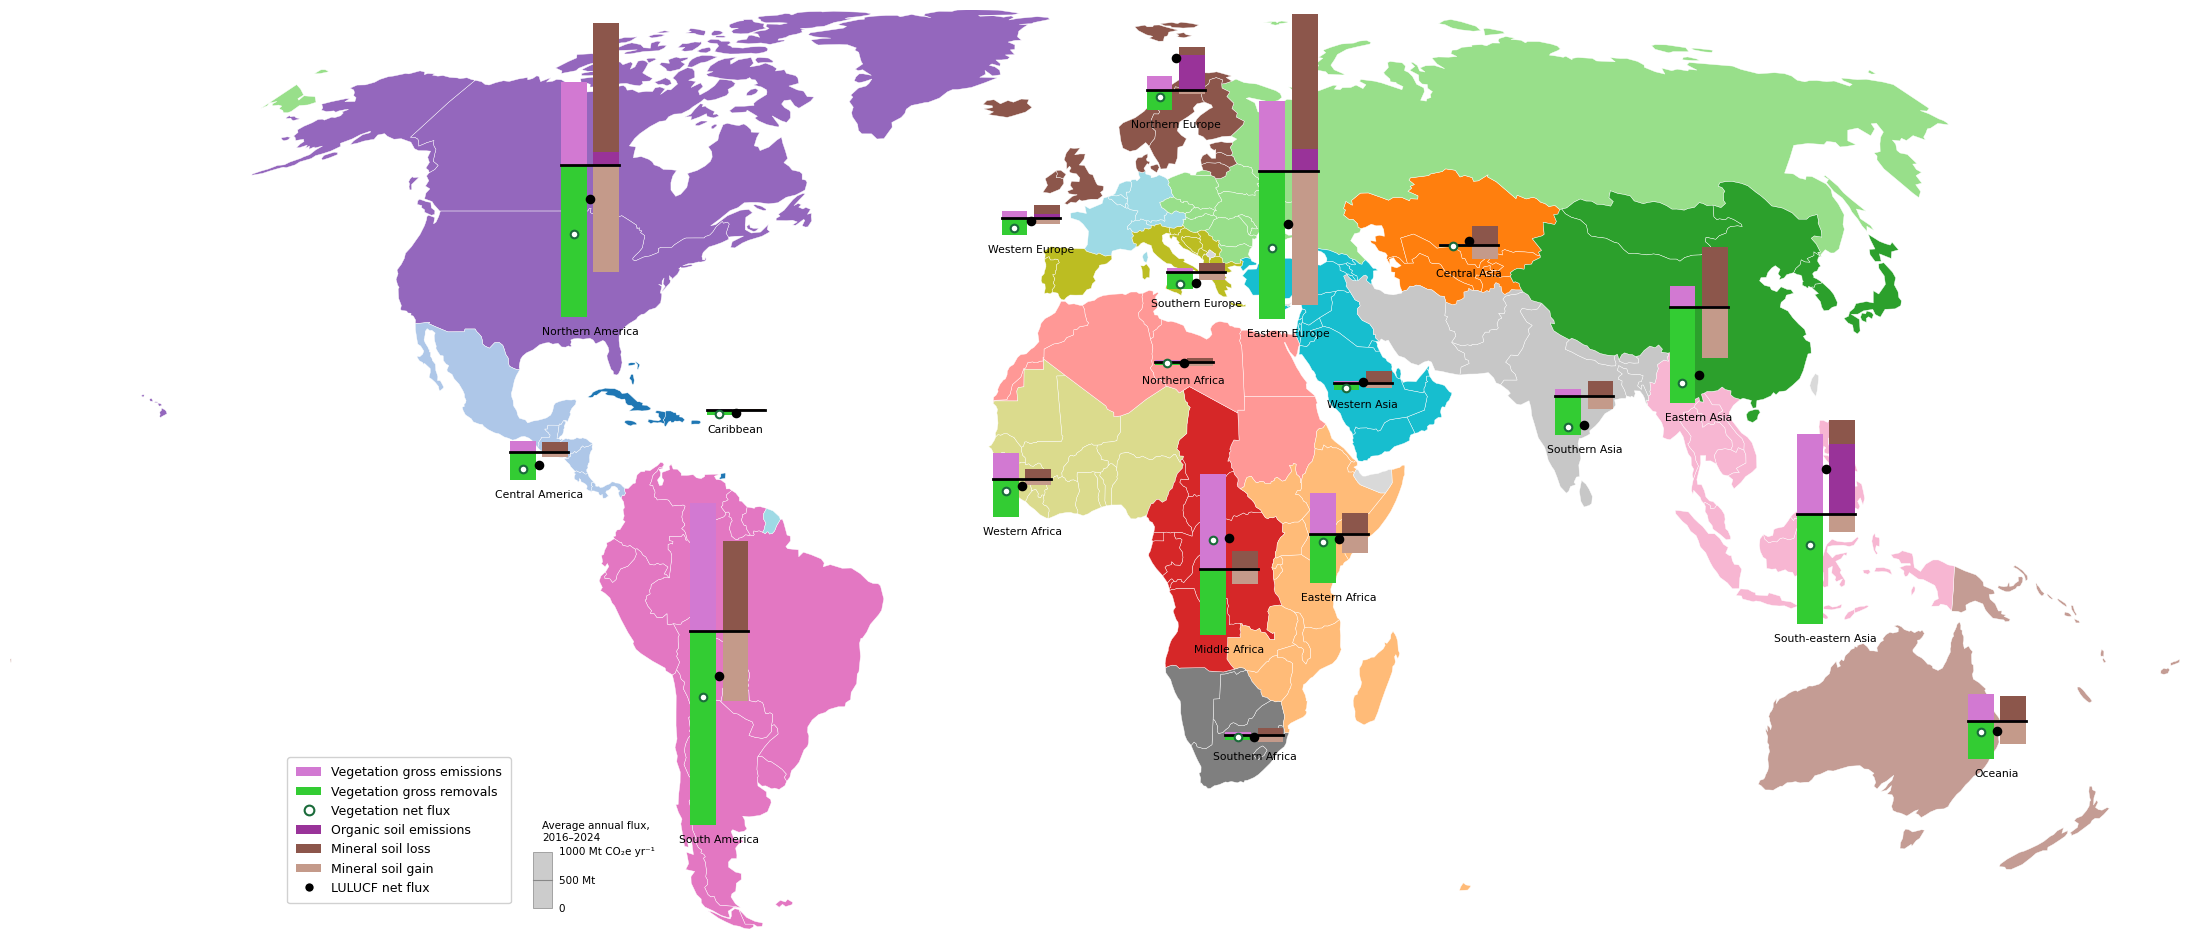

In [12]:
### Pan et al. 2024-style regional map: average annual LULUCF component fluxes by UN geoscheme region
### From Claude sessions 'Pan et al. regional LULUCF flux map' and 'LULUCF and component table creation'

# ── Data prep ────────────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()

COMP_COLS = {
    'veg_gross_emis':   COL_VEG_EMIS,
    'veg_gross_remov':  COL_VEG_REMOV,
    'veg_net':          'net_flux__all_C_pools__all_gases__MgCO2e',
    'mineral_soil_loss': COL_MINERAL_SOIL_LOSS,
    'mineral_soil_gain': COL_MINERAL_SOIL_GAIN,
    'organic_soil':     COL_ORGANIC_SOIL,
    'total_LULUCF':     COL_LULUCF_NET,
}

df["map_region"] = np.where(
    df["region_L1"] == "Oceania", "Oceania", df["region_L2_L3"]
)
df = df[
    df["map_region"].notna()
    & ~df["map_region"].isin(["Antarctica", "Unassigned", "unassigned"])
].copy()

regional_wide = (
    df
    .groupby("map_region")[list(COMP_COLS.values())]
    .sum()
    .div(n_years)
    .rename(columns={v: k for k, v in COMP_COLS.items()})
)

# ── Map setup ────────────────────────────────────────────────────────────────
ROBINSON_CRS = cn.Robinson_crs

def _iso_to_map_region(iso):
    if not isinstance(iso, str) or iso == "-99":
        return None
    if cn.iso_to_region_UN_geoscheme_L1.get(iso) == "Oceania":
        return "Oceania"
    return cn.iso_to_region_UN_geoscheme_L2_L3.get(iso)

try:
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
except AttributeError:
    _ne_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(_ne_url)
    world = world.rename(columns={"ISO_A3_EH": "iso_a3"})

world = world[world["iso_a3"] != "ATA"].copy()
world["map_region"] = world["iso_a3"].map(_iso_to_map_region)

all_regions_sorted = sorted([
    "Northern Africa", "Western Africa", "Middle Africa", "Eastern Africa", "Southern Africa",
    "Northern Europe", "Western Europe", "Southern Europe", "Eastern Europe",
    "Western Asia", "Central Asia", "Southern Asia", "Eastern Asia", "South-eastern Asia",
    "Northern America", "Central America", "Caribbean", "South America", "Oceania",
])
_cmap = plt.colormaps["tab20"].resampled(len(all_regions_sorted))
REGION_COLORS = {region: mcolors.to_hex(_cmap(i)) for i, region in enumerate(all_regions_sorted)}

world["map_color"] = world["map_region"].map(lambda r: REGION_COLORS.get(r, "#d9d9d9"))
world = world.to_crs(ROBINSON_CRS)

BAR_POSITIONS_WGS84 = {
    "Northern Africa":    ( 15,  27),
    "Western Africa":     (-12,  10),
    "Middle Africa":      ( 22,  -3),
    "Eastern Africa":     ( 40,   2),
    "Southern Africa":    ( 27, -27),
    "Northern Europe":    ( 18,  68),
    "Western Europe":     (-12,  48),
    "Southern Europe":    ( 18,  40),
    "Eastern Europe":     ( 38,  55),
    "Western Asia":       ( 45,  24),
    "Central Asia":       ( 68,  44),
    "Southern Asia":      ( 82,  22),
    "Eastern Asia":       (105,  35),
    "South-eastern Asia": (120,   5),
    "Northern America":   (-100,  56),
    "Central America":    ( -92,  14),
    "Caribbean":          ( -60,  20),
    "South America":      ( -62, -12),
    "Oceania":            ( 152, -25),
}

_anchor_gdf = gpd.GeoDataFrame(
    {"region": list(BAR_POSITIONS_WGS84.keys())},
    geometry=[Point(lon, lat) for lon, lat in BAR_POSITIONS_WGS84.values()],
    crs="EPSG:4326",
).to_crs(ROBINSON_CRS)

BAR_POSITIONS = {
    row["region"]: (row.geometry.x, row.geometry.y)
    for _, row in _anchor_gdf.iterrows()
}

COMP_COLORS = {
    "veg_gross_emis":    "#d279d2",
    "veg_gross_remov":   "#33cc33",
    "organic_soil":      "#993399",
    "mineral_soil_loss": "#8c564b",
    "mineral_soil_gain": "#c49a8a",
}
VEG_NET_EDGE_COLOR = "#1a6b3a"

SUB_HW   = 200_000
HALF_GAP = 50_000

comp_cols_for_scale = ["veg_gross_emis", "veg_gross_remov",
                       "organic_soil", "mineral_soil_loss", "mineral_soil_gain"]
max_abs = regional_wide[comp_cols_for_scale].abs().max().max()
SCALE   = 3_000_000 / max_abs

fig, ax = plt.subplots(figsize=(22, 11))
ax.set_aspect("equal")
ax.set_axis_off()

bounds = world.total_bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

world.plot(ax=ax, color=world["map_color"].tolist(), edgecolor="white", linewidth=0.3, zorder=1)

for region, row in regional_wide.iterrows():
    if region not in BAR_POSITIONS:
        continue
    cx, cy = BAR_POSITIONS[region]
    cx_veg  = cx - SUB_HW - HALF_GAP
    cx_soil = cx + SUB_HW + HALF_GAP
    veg_left  = cx_veg  - SUB_HW
    soil_left = cx_soil - SUB_HW

    # ── Vegetation bar (gross emis stacked positive, gross remov negative) ──
    veg_pos_top = veg_neg_bot = 0.0
    for comp in ["veg_gross_emis", "veg_gross_remov"]:
        val = row.get(comp, np.nan)
        if pd.isna(val):
            continue
        h = val * SCALE
        bottom = veg_pos_top if val >= 0 else veg_neg_bot
        if val >= 0: veg_pos_top += h
        else:        veg_neg_bot += h
        ax.add_patch(mpatches.Rectangle(
            (veg_left, cy + bottom), SUB_HW * 2, h,
            facecolor=COMP_COLORS[comp], edgecolor="none", zorder=4,
        ))

    # ── Soil bar: organic + mineral loss stacked positive,
    #              mineral gain stacked negative ────────────────────────────
    soil_pos_top = soil_neg_bot = 0.0
    for comp in ["organic_soil", "mineral_soil_loss", "mineral_soil_gain"]:
        val = row.get(comp, np.nan)
        if pd.isna(val):
            continue
        h = val * SCALE
        bottom = soil_pos_top if val >= 0 else soil_neg_bot
        if val >= 0: soil_pos_top += h
        else:        soil_neg_bot += h
        ax.add_patch(mpatches.Rectangle(
            (soil_left, cy + bottom), SUB_HW * 2, h,
            facecolor=COMP_COLORS[comp], edgecolor="none", zorder=4,
        ))

    soil_right = cx_soil + SUB_HW
    ax.plot([veg_left, soil_right], [cy, cy], color="black", linewidth=2.0, zorder=5)

    veg_net = row.get("veg_net", np.nan)
    if not pd.isna(veg_net):
        ax.scatter(cx_veg, cy + veg_net * SCALE, s=30, zorder=6,
                   facecolors="white", edgecolors=VEG_NET_EDGE_COLOR, linewidths=1.5)

    lulucf_net = row.get("total_LULUCF", np.nan)
    if not pd.isna(lulucf_net):
        ax.scatter(cx, cy + lulucf_net * SCALE, s=35, color="black", zorder=6)

    overall_neg_bot = min(veg_neg_bot, soil_neg_bot, 0)
    ax.text(cx, cy + overall_neg_bot - 150_000, region,
            ha="center", va="top", fontsize=7.8, zorder=7)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=COMP_COLORS["veg_gross_emis"],    label="Vegetation gross emissions"),
    mpatches.Patch(facecolor=COMP_COLORS["veg_gross_remov"],   label="Vegetation gross removals"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=7,
               markerfacecolor="white", markeredgecolor=VEG_NET_EDGE_COLOR,
               markeredgewidth=1.5,                            label="Vegetation net flux"),
    mpatches.Patch(facecolor=COMP_COLORS["organic_soil"],      label="Organic soil emissions"),
    mpatches.Patch(facecolor=COMP_COLORS["mineral_soil_loss"], label="Mineral soil loss"),
    mpatches.Patch(facecolor=COMP_COLORS["mineral_soil_gain"], label="Mineral soil gain"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=7,
               markerfacecolor="black",                        label="LULUCF net flux"),
]
ax.legend(handles=legend_handles,
          bbox_to_anchor=(bounds[0] + 4_200_000, bounds[1] + 300_000),
          bbox_transform=ax.transData, loc="lower left",
          fontsize=9, framealpha=0.9, borderpad=0.7)

# ── Scale box ────────────────────────────────────────────────────────────────
sb_x  = bounds[0] + 8_100_000
sb_y  = bounds[1] + 320_000
ref_w = SUB_HW * 1.5
ref_h_500  = 500e6  * SCALE
ref_h_1000 = 1000e6 * SCALE

ax.text(sb_x + ref_w / 2, sb_y + ref_h_1000 + 150_000,
        "Average annual flux, \n2016–2024",
        ha="left", va="bottom", fontsize=7.5, zorder=8)

ax.add_patch(mpatches.Rectangle(
    (sb_x, sb_y), ref_w, ref_h_1000,
    facecolor="#cccccc", edgecolor="#888888", linewidth=0.5, zorder=7,
))
ax.plot([sb_x, sb_x + ref_w], [sb_y + ref_h_500, sb_y + ref_h_500],
        color="#888888", linewidth=0.8, zorder=8)

tick_x = sb_x + ref_w + 100_000
ax.text(tick_x, sb_y,              "0",                  va="center", fontsize=7.5, zorder=8)
ax.text(tick_x, sb_y + ref_h_500,  "500 Mt",             va="center", fontsize=7.5, zorder=8)
ax.text(tick_x, sb_y + ref_h_1000, "1000 Mt CO₂e yr⁻¹", va="center", fontsize=7.5, zorder=8)

plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/regional_map_flux_bar_graphs_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

  Emis: short veg & cropland    : +0.51 Gt CO2e/yr
  Emis: partially disturbed     : +1.67 Gt CO2e/yr
  Emis: tree cover loss         : +7.54 Gt CO2e/yr
  Mineral soil loss             : +10.84 Gt CO2e/yr
  Organic soil (combined)       : +2.57 Gt CO2e/yr
  Remov: undisturbed            : -17.03 Gt CO2e/yr
  Remov: new tree cover         : -0.23 Gt CO2e/yr
  Mineral soil gain             : -9.14 Gt CO2e/yr
  LULUCF net flux               : -3.14 Gt CO2e/yr


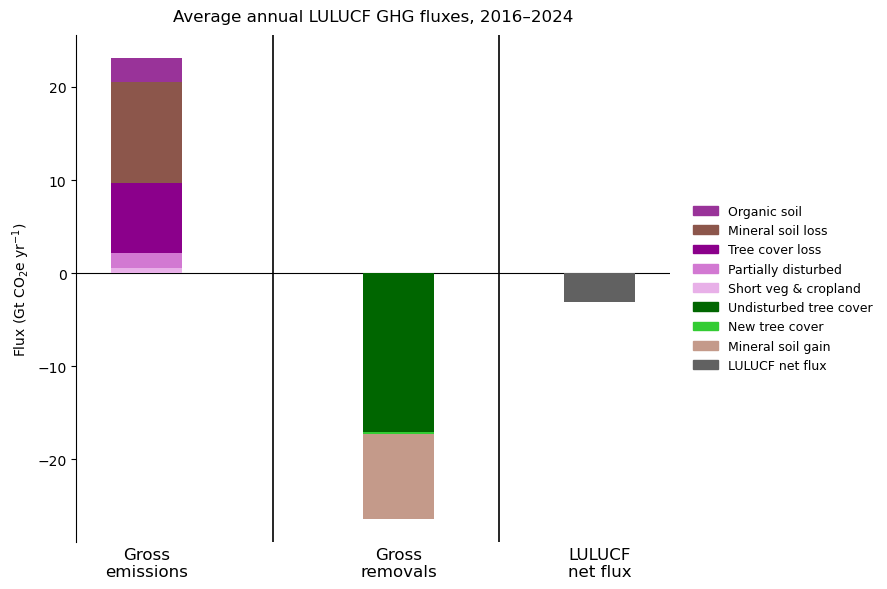

In [14]:
### Average annual fluxes bar chart: gross emissions | gross removals | net flux
### With Claude sessions "Annual net fluxes bar graph" and 'LULUCF and component table creation'

# ── Colors ────────────────────────────────────────────────────────────────────
C_EMIS_NONTALL  = "#e8b0e8"
C_EMIS_DISTURB  = "#d279d2"
C_EMIS_LOSS     = "#8b008b"
C_MIN_SOIL_LOSS = "#8c564b"
C_MIN_SOIL_GAIN = "#c49a8a"
C_ORG_SOIL      = "#993399"

C_REMOV_UNDIST  = "#006600"
C_REMOV_NEW     = "#33cc33"

C_NET           = "#616161"

# ── Data aggregation ──────────────────────────────────────────────────────────
df = LULUCF_for_figures.copy()
df['year'] = df['year'].astype(int)
n_years = df['year'].nunique()

dlc  = df['land_state_detailed_class']
lsbc = df['land_state_broad_class']

def _Gt(mask, col):
    return df.loc[mask, col].sum() / n_years / 1e9

# Gross emissions by vegetation class
veg_emis_nontall_Gt  = _Gt(lsbc != 'tree',                                                    COL_VEG_EMIS)
veg_emis_disturb_Gt  = _Gt(dlc.isin(['tree_tree_disturbed', 'tree_tree_disturbed_fire_only']), COL_VEG_EMIS)
veg_emis_loss_Gt     = _Gt(dlc == 'tree_loss',                                                COL_VEG_EMIS)
mineral_soil_loss_Gt = df[COL_MINERAL_SOIL_LOSS].sum() / n_years / 1e9
org_soil_Gt          = df[COL_ORGANIC_SOIL].sum()      / n_years / 1e9

# Gross removals by vegetation class
veg_remov_undist_Gt  = _Gt(dlc == 'tree_tree_undisturbed', COL_VEG_REMOV)
veg_remov_new_Gt     = _Gt(dlc == 'tree_gain',             COL_VEG_REMOV)
mineral_soil_gain_Gt = df[COL_MINERAL_SOIL_GAIN].sum() / n_years / 1e9

# Net flux
lulucf_net_Gt = df[COL_LULUCF_NET].sum() / n_years / 1e9

# QC print
for lbl, val in [
    ("Emis: short veg & cropland",  veg_emis_nontall_Gt),
    ("Emis: partially disturbed",   veg_emis_disturb_Gt),
    ("Emis: tree cover loss",       veg_emis_loss_Gt),
    ("Mineral soil loss",           mineral_soil_loss_Gt),
    ("Organic soil (combined)",     org_soil_Gt),
    ("Remov: undisturbed",          veg_remov_undist_Gt),
    ("Remov: new tree cover",       veg_remov_new_Gt),
    ("Mineral soil gain",           mineral_soil_gain_Gt),
    ("LULUCF net flux",             lulucf_net_Gt),
]:
    print(f"  {lbl:<30s}: {val:+.2f} Gt CO2e/yr")

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

x_emis, x_remov, x_net = 0.0, 2.5, 4.5
bar_w = 0.7

# Gross emissions — stacked upward
ax.bar(x_emis, veg_emis_nontall_Gt,  width=bar_w, color=C_EMIS_NONTALL,  zorder=2)
ax.bar(x_emis, veg_emis_disturb_Gt,  width=bar_w, color=C_EMIS_DISTURB,
       bottom=veg_emis_nontall_Gt, zorder=2)
ax.bar(x_emis, veg_emis_loss_Gt,     width=bar_w, color=C_EMIS_LOSS,
       bottom=veg_emis_nontall_Gt + veg_emis_disturb_Gt, zorder=2)
ax.bar(x_emis, mineral_soil_loss_Gt, width=bar_w, color=C_MIN_SOIL_LOSS,
       bottom=veg_emis_nontall_Gt + veg_emis_disturb_Gt + veg_emis_loss_Gt, zorder=2)
ax.bar(x_emis, org_soil_Gt,          width=bar_w, color=C_ORG_SOIL,
       bottom=veg_emis_nontall_Gt + veg_emis_disturb_Gt + veg_emis_loss_Gt + mineral_soil_loss_Gt, zorder=2)

# Gross removals — stacked downward
ax.bar(x_remov, veg_remov_undist_Gt,  width=bar_w, color=C_REMOV_UNDIST, zorder=2)
ax.bar(x_remov, veg_remov_new_Gt,     width=bar_w, color=C_REMOV_NEW,
       bottom=veg_remov_undist_Gt, zorder=2)
ax.bar(x_remov, mineral_soil_gain_Gt, width=bar_w, color=C_MIN_SOIL_GAIN,
       bottom=veg_remov_undist_Gt + veg_remov_new_Gt, zorder=2)

# Net flux
ax.bar(x_net, lulucf_net_Gt, width=bar_w, color=C_NET, zorder=2)

# Zero line and section dividers
ax.axhline(0, color="black", linewidth=0.8, zorder=1)
ax.axvline((x_emis + x_remov) / 2, color="black", linewidth=1.2, zorder=1)
ax.axvline((x_remov + x_net)  / 2, color="black", linewidth=1.2, zorder=1)

# Axes formatting
ax.set_xticks([x_emis, x_remov, x_net])
ax.set_xticklabels(["Gross\nemissions", "Gross\nremovals", "LULUCF\nnet flux"])
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
ax.set_title(
    f"Average annual LULUCF GHG fluxes, "
    f"{cn.interval_end_years_annual[0]}–{cn.interval_end_years_annual[-1]}",
    pad=10,
)
ax.set_xlim(x_emis - bar_w, x_net + bar_w)
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", length=0, labelsize=12)

# Legend
legend_handles = [
    mpatches.Patch(color=C_ORG_SOIL,      label="Organic soil"),
    mpatches.Patch(color=C_MIN_SOIL_LOSS,  label="Mineral soil loss"),
    mpatches.Patch(color=C_EMIS_LOSS,      label="Tree cover loss"),
    mpatches.Patch(color=C_EMIS_DISTURB,   label="Partially disturbed"),
    mpatches.Patch(color=C_EMIS_NONTALL,   label="Short veg & cropland"),
    mpatches.Patch(color=C_REMOV_UNDIST,   label="Undisturbed tree cover"),
    mpatches.Patch(color=C_REMOV_NEW,      label="New tree cover"),
    mpatches.Patch(color=C_MIN_SOIL_GAIN,  label="Mineral soil gain"),
    mpatches.Patch(color=C_NET,            label="LULUCF net flux"),
]
ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=9)

plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/average_annual_bar_graphs_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

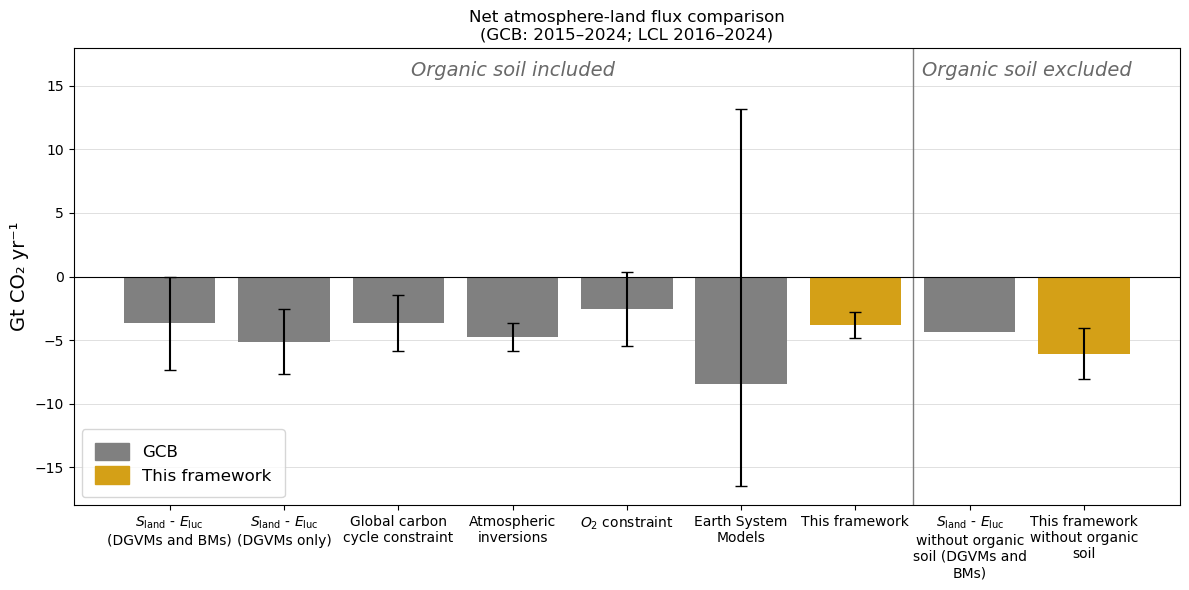

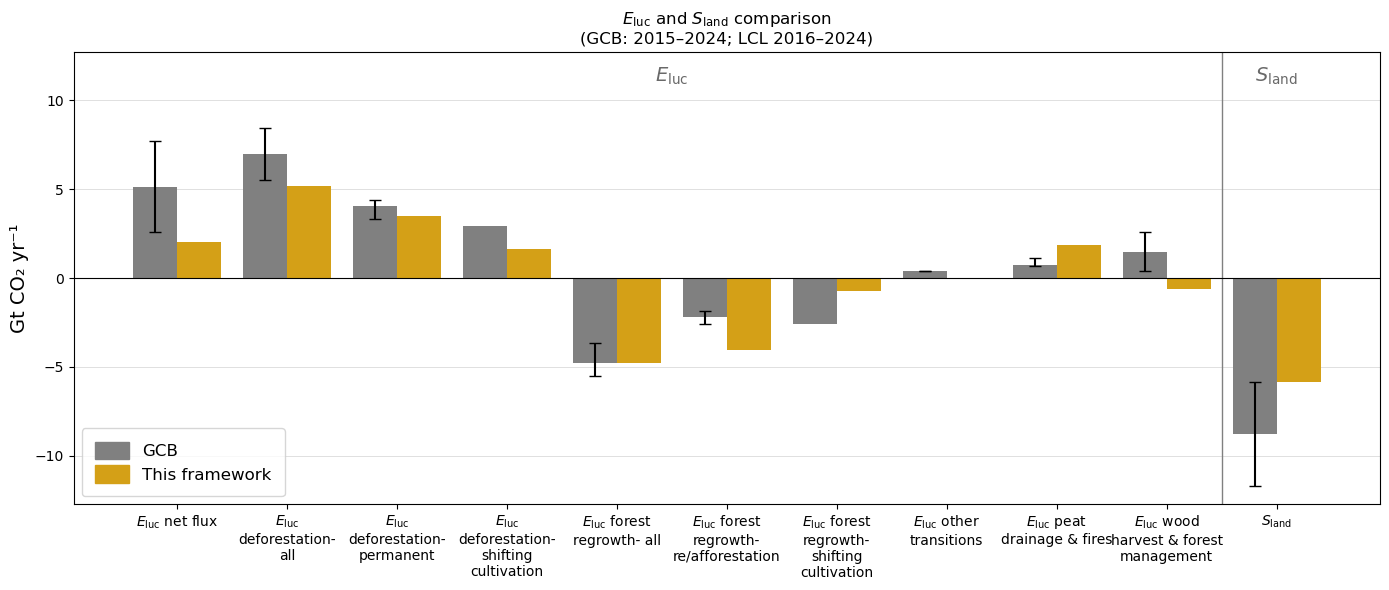

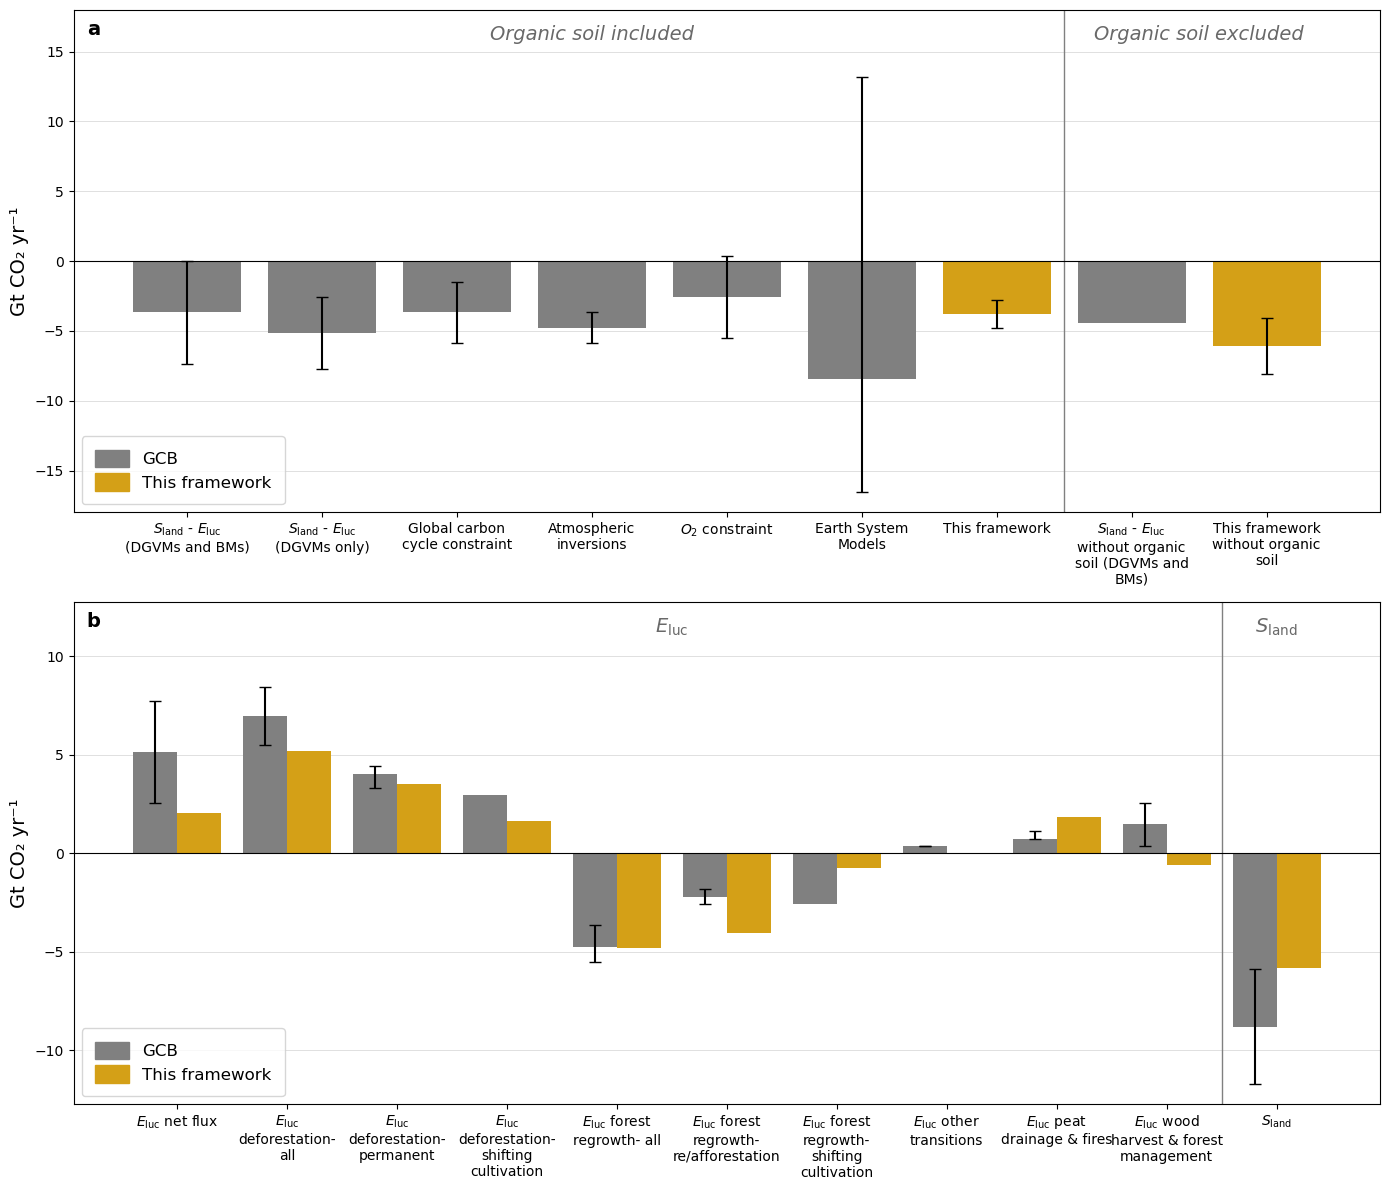

=== Panel a: Net atmosphere-land flux ===

Label                                         Source       Flux          Uncertainty
-----------------------------------------------------------------------------------
S_land - E_luc (DGVMs and BMs)                   GCB      -3.67                ±3.67
S_land - E_luc (DGVMs only)                      GCB      -5.13                ±2.57
Global carbon cycle constraint                   GCB      -3.67                ±2.20
Atmospheric inversions                           GCB      -4.77                ±1.10
O2 constraint                                    GCB      -2.57                ±2.93
Earth System Models                              GCB      -8.43         +21.63/-8.06
This framework                                   LCL      -3.82                ±1.00
S_land - E_luc without organic soil (DGVMs and BMs)    GCB      -4.40                  N/A
This framework without organic soil              LCL      -6.05                ±2.00

=== Panel b: E_l

In [43]:
### Global Carbon Budget comparison bar graphs.
### Uses an Excel spreadsheet in which I've already aggregated the GCB values and calculated the LCL values (i.e. translated the LCL values to GCB).
### So, the actual workflow for this is: create LULUCF pandas dataframe from flox zonal stats runs -> ingest into Postgres table -> query postgres table and put results in Excel -> perform GCB translation -> run this script
### I decided it was easier to calculate translated LULUCF framework values and write notes about GCB and LCL data in Excel than doing all of it in a Jupyter notebook. Hence, this route that goes through Excel. 
### With Claude session 'LULUCF vs Global Carbon Budget graphs'

EXCEL_PATH = (
    '/mnt/c/Users/David.Gibbs/OneDrive - World Resources Institute/Documents/Projects'
    '/AFOLU_flux_model__all_land_all_carbon/LULUCF/Global_Carbon_Budget_comparison'
    '/LCL_LULUCF_vs_GCB_land_20260610.xlsx'
)
GCB_COLOR = '#808080'
LCL_COLOR = '#D4A017'

raw = pd.read_excel(EXCEL_PATH, sheet_name='comparison', header=0)
raw = raw.iloc[:, [1, 4, 5, 12, 13, 16]].copy()
raw.columns = ['gcb_label', 'gcb_flux', 'gcb_stdev', 'lcl_label', 'lcl_flux', 'lcl_stdev']

def ix(excel_rows):
    return [r - 2 for r in excel_rows]

def wrap_label(s, width=16):
    return '\n'.join(textwrap.wrap(str(s), width=width))

def format_label(s, width=16):
    wrapped = wrap_label(str(s), width=width)
    wrapped = wrapped.replace('E_luc', r'$E_{\mathrm{luc}}$')
    wrapped = wrapped.replace('S_land', r'$S_{\mathrm{land}}$')
    wrapped = re.sub(r'\bO2\b', r'$O_2$', wrapped)
    return wrapped

def parse_stdev(val, central=None):
    if pd.isna(val):
        return np.nan, np.nan
    s = str(val).strip()
    if s.upper() == 'N/A':
        return np.nan, np.nan
    m = re.match(r'\[\s*([+-]?\d*\.?\d+)\s*,\s*([+-]?\d*\.?\d+)\s*\]', s)
    if m:
        lo, hi = float(m.group(1)), float(m.group(2))
        if central is not None:
            return abs(float(central) - lo), abs(hi - float(central))
        return np.nan, np.nan
    try:
        v = float(s)
        return abs(v), abs(v)
    except ValueError:
        return np.nan, np.nan

def add_errorbars(ax, x, y, lo, hi):
    if not (np.isnan(lo) or np.isnan(hi)):
        ax.errorbar(x, y, yerr=[[lo], [hi]], fmt='none',
                    ecolor='black', capsize=4, elinewidth=1.5)

legend_kw = dict(loc='lower left', fontsize=12, handlelength=2.0,
                 handleheight=1.2, borderpad=0.8, labelspacing=0.4)
legend_handles = [
    mpatches.Patch(color=GCB_COLOR, label='GCB'),
    mpatches.Patch(color=LCL_COLOR, label='This framework'),
]

# ── Data prep ─────────────────────────────────────────────────────────────────
gcb_L = raw.iloc[ix([2, 3, 4, 5, 7, 8, 9])].reset_index(drop=True)
lcl_L = raw.iloc[ix([8, 9])].reset_index(drop=True)

bars_L = []
for i in range(6):
    bars_L.append({'label': gcb_L.iloc[i]['gcb_label'], 'flux': gcb_L.iloc[i]['gcb_flux'],
                   'stdev': gcb_L.iloc[i]['gcb_stdev'], 'color': GCB_COLOR})
bars_L.append({'label': lcl_L.iloc[0]['lcl_label'], 'flux': lcl_L.iloc[0]['lcl_flux'],
               'stdev': lcl_L.iloc[0]['lcl_stdev'], 'color': LCL_COLOR})
no_organic_start = len(bars_L)   # = 7
bars_L.append({'label': gcb_L.iloc[6]['gcb_label'], 'flux': gcb_L.iloc[6]['gcb_flux'],
               'stdev': gcb_L.iloc[6]['gcb_stdev'], 'color': GCB_COLOR})
bars_L.append({'label': lcl_L.iloc[1]['lcl_label'], 'flux': lcl_L.iloc[1]['lcl_flux'],
               'stdev': lcl_L.iloc[1]['lcl_stdev'], 'color': LCL_COLOR})

mid_included  = (no_organic_start - 1) / 2        # centre of positions 0–6  = 3.0
mid_excluded  = (no_organic_start + len(bars_L) - 1) / 2   # centre of 7–8 = 7.5

both_R = raw.iloc[ix([11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 25])].reset_index(drop=True)
x_c = np.arange(len(both_R))
bw  = 0.4

# ── Panel draw functions ──────────────────────────────────────────────────────
def draw_left(ax, show_title=True):
    ax.yaxis.grid(True, linewidth=0.5, color='lightgrey')
    ax.set_axisbelow(True)
    for i, bar in enumerate(bars_L):
        lo, hi = parse_stdev(bar['stdev'], bar['flux'])
        ax.bar(i, bar['flux'], color=bar['color'])
        add_errorbars(ax, i, bar['flux'], lo, hi)

    # Section divider and labels (xaxis transform: data-x, axes-fraction-y)
    ax.axvline(x=no_organic_start - 0.5, color='gray', linewidth=1.0)
    ax.text(mid_included, 0.97, 'Organic soil included',
            ha='center', va='top', fontsize=14, color='dimgray', style='italic',
            transform=ax.get_xaxis_transform())
    ax.text(mid_excluded, 0.97, 'Organic soil excluded',
            ha='center', va='top', fontsize=14, color='dimgray', style='italic',
            transform=ax.get_xaxis_transform())

    ax.set_xticks(np.arange(len(bars_L)))
    ax.set_xticklabels([format_label(bar['label']) for bar in bars_L],
                   rotation=0, ha='center', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Gt CO₂ yr⁻¹', fontsize=14)
    if show_title:
        ax.set_title('Net atmosphere-land flux comparison\n(GCB: 2015–2024; LCL 2016–2024)')
    ax.legend(handles=legend_handles, **legend_kw)
    yabs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
    ax.set_ylim(-yabs, yabs)

def draw_right(ax, show_title=True):
    ax.yaxis.grid(True, linewidth=0.5, color='lightgrey')
    ax.set_axisbelow(True)
    ax.bar(x_c - bw / 2, both_R['gcb_flux'], width=bw, color=GCB_COLOR)
    for i, row in both_R.iterrows():
        lo, hi = parse_stdev(row['gcb_stdev'], row['gcb_flux'])
        add_errorbars(ax, x_c[i] - bw / 2, row['gcb_flux'], lo, hi)
    ax.bar(x_c + bw / 2, both_R['lcl_flux'], width=bw, color=LCL_COLOR)
    for i, row in both_R.iterrows():
        lo, hi = parse_stdev(row['lcl_stdev'], row['lcl_flux'])
        add_errorbars(ax, x_c[i] + bw / 2, row['lcl_flux'], lo, hi)

    # Section divider and labels
    s_land_x = x_c[-1]                      # position of S_land bar group = 10
    mid_eluc  = (x_c[0] + x_c[-2]) / 2     # centre of E_luc bars (0–9) = 4.5
    ax.axvline(x=s_land_x - 0.5, color='gray', linewidth=1.0)
    ax.text(mid_eluc, 0.97, r'$E_{\mathrm{luc}}$',
            ha='center', va='top', fontsize=14, color='dimgray',
            transform=ax.get_xaxis_transform())
    ax.text(s_land_x, 0.97, r'$S_{\mathrm{land}}$',
            ha='center', va='top', fontsize=14, color='dimgray',
            transform=ax.get_xaxis_transform())

    ax.set_xticks(x_c)
    ax.set_xticklabels([format_label(l) for l in both_R['gcb_label']],
                   rotation=0, ha='center', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Gt CO₂ yr⁻¹', fontsize=14)
    if show_title:
        ax.set_title(r'$E_{\mathrm{luc}}$ and $S_{\mathrm{land}}$ comparison'
                     '\n(GCB: 2015–2024; LCL 2016–2024)')
    ax.legend(handles=legend_handles, **legend_kw)
    yabs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
    ax.set_ylim(-yabs, yabs)

# ── Individual figure a ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 6))
draw_left(ax1)
plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_GCB_land_atmos_flux_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Individual figure b ───────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6))
draw_right(ax2)
plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_GCB_Eluc_Sland_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Combined figure (a above b) ───────────────────────────────────────────────
fig_c, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(14, 12))
draw_left(ax_a, show_title=False)
draw_right(ax_b, show_title=False)
for ax, label in zip([ax_a, ax_b], ['a', 'b']):
    ax.text(0.01, 0.98, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')
plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_GCB_two_panel_comparison_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ── Print values ──────────────────────────────────────────────────────────────
def fmt_err(val, central=None):
    lo, hi = parse_stdev(val, central)
    if np.isnan(lo):
        return 'N/A'
    return f'±{lo:.2f}' if lo == hi else f'+{hi:.2f}/-{lo:.2f}'

print('=== Panel a: Net atmosphere-land flux ===')
print(f'\n{"Label":<45} {"Source":>6} {"Flux":>10} {"Uncertainty":>20}')
print('-' * 83)
for bar in bars_L:
    src = 'GCB' if bar['color'] == GCB_COLOR else 'LCL'
    print(f'{str(bar["label"]):<45} {src:>6} {bar["flux"]:>10.2f} {fmt_err(bar["stdev"], bar["flux"]):>20}')

print('\n=== Panel b: E_luc and S_land ===')
print(f'\n{"Label":<45} {"GCB flux":>10} {"GCB uncert":>15} {"LCL flux":>10} {"LCL uncert":>15}')
print('-' * 97)
for _, row in both_R.iterrows():
    print(f'{str(row["gcb_label"]):<45} {row["gcb_flux"]:>10.2f} '
          f'{fmt_err(row["gcb_stdev"], row["gcb_flux"]):>15} '
          f'{row["lcl_flux"]:>10.2f} {fmt_err(row["lcl_stdev"], row["lcl_flux"]):>15}')

In [ ]:
### Global SOC gross loss, gain, and net change by block: full extent only (gain positive, loss negative, counter to LULUCF standard)
### Per Claude session 'LULUCF and component table creation'

# ── Data ─────────────────────────────────────────────────────────────────────
FULL_LOSS = 'SOC_loss__full_extent__0-30cm_MgCO2'
FULL_GAIN = 'SOC_gain__full_extent__0-30cm_MgCO2'
FULL_NET  = 'SOC_net__full_extent__0-30cm_MgCO2'

df_soc = SOC_df_raw[SOC_df_raw['analysis_layer'].isin([FULL_LOSS, FULL_GAIN, FULL_NET])].copy()

year_totals = (
    df_soc
    .groupby(['year', 'analysis_layer'])['zonal_stats_sum']
    .sum()
    .div(1e9)
    .unstack('analysis_layer')
    .rename_axis(None, axis=1)
    .sort_index()
)

years = year_totals.index.tolist()
x = np.arange(len(years))

# Flip signs: gain → positive, loss → negative, net → flipped accordingly
loss_vals = -year_totals[FULL_LOSS].values   # was positive, now negative
gain_vals = -year_totals[FULL_GAIN].values   # was negative, now positive
net_vals  = -year_totals[FULL_NET].values

# ── Colors (distinct for this figure) ────────────────────────────────────────
C_LOSS = "#8b008b"   # dark magenta — loss (emission)
C_GAIN = "#33cc33"   # bright green — gain (removal)
C_NET  = "#000000"   # black   — net

# ── Plot ──────────────────────────────────────────────────────────────────────
bar_w = 0.6

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x, loss_vals, width=bar_w, color=C_LOSS, zorder=2, label='Loss')
ax.bar(x, gain_vals, width=bar_w, color=C_GAIN, zorder=2, label='Gain')
ax.plot(x, net_vals, color=C_NET, marker='o', linewidth=1.8, zorder=4, label='Net change')

ax.axhline(0, color='black', linewidth=0.8, zorder=1)
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Gt CO₂ per year')
ax.set_title('Global SOC loss and gain, full extent, 0–30 cm', fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_handles = [
    mpatches.Patch(color=C_GAIN, label='Gain'),
    mpatches.Patch(color=C_LOSS, label='Loss'),
    plt.Line2D([0], [0], color=C_NET, marker='o', linewidth=1.8, label='Net change'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=9)

plt.tight_layout()
# plt.savefig(f'{LULUCF_zonal_stats_folder}/SOC_loss_gain_full_extent_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

display(year_totals[[FULL_LOSS, FULL_GAIN, FULL_NET]].round(3))